# Cross Signal Correlation

This will compare SBERT Similarity Score vs Soft Compatibility Labels 

we have SBERT pairwise similarities (from Experiment A) and soft compatibility scores (from Experiment B), but on different profile samples. The plan here is to re-run both on the same set of profile pairs so you can actually correlate text similarity with attribute compatibility. This tests whether semantically similar profiles (by essay text) also tend to be attribute-compatible — a core hypothesis of the project.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read dataset
okCupid = pd.read_csv("./data/okcupid_profiles.csv")

In [3]:
# 1. Basic info
print(okCupid.shape)
print(okCupid.dtypes)
print(okCupid.head(3).to_string())

# 2. Missing values
print(okCupid.isnull().mean().sort_values(ascending=False))

# 3. Summary stats for numeric cols
print(okCupid.describe())

# 4. Essay fields — how much text do people actually write?
essay_cols = [c for c in okCupid.columns if c.startswith('essay')]
print("Essay columns:", essay_cols)
for col in essay_cols:
    filled = okCupid[col].notna().mean()
    avg_len = okCupid[col].dropna().str.len().mean()
    print(f"{col}: {filled:.1%} filled, avg {avg_len:.0f} chars")

# 6. Categorical distributions
for col in ['sex', 'status', 'education', 'religion', 'diet']:
    print(f"\n{col}:\n", okCupid[col].value_counts(normalize=True).head(6))

(59946, 31)
age              int64
status          object
sex             object
orientation     object
body_type       object
diet            object
drinks          object
drugs           object
education       object
ethnicity       object
height         float64
income           int64
job             object
last_online     object
location        object
offspring       object
pets            object
religion        object
sign            object
smokes          object
speaks          object
essay0          object
essay1          object
essay2          object
essay3          object
essay4          object
essay5          object
essay6          object
essay7          object
essay8          object
essay9          object
dtype: object
   age     status sex orientation       body_type               diet    drinks      drugs                       education     ethnicity  height  income                   job       last_online                         location                               offspr

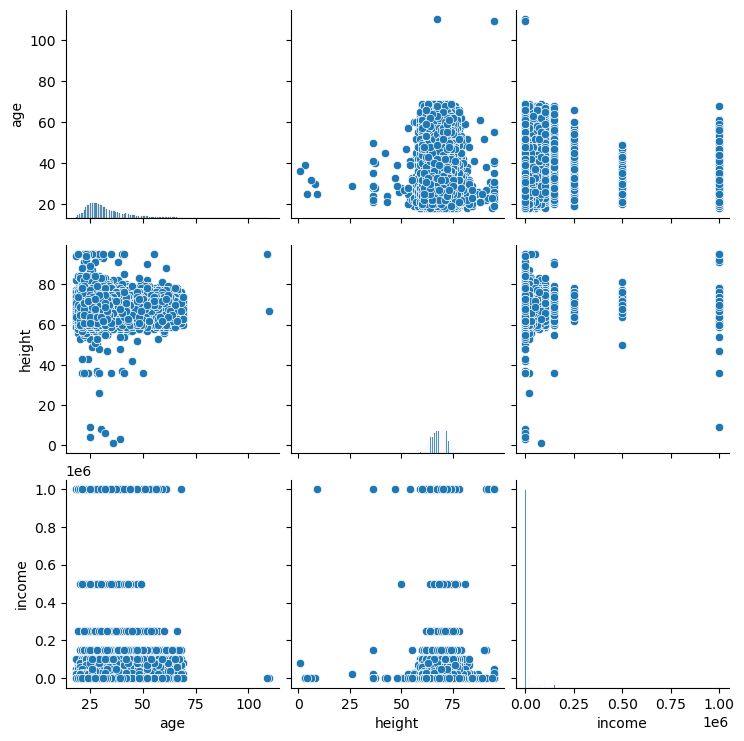

In [4]:
# 5. Scatterplot matrix of key numeric cols
numeric_cols = ['age', 'height', 'income']
sns.pairplot(okCupid[numeric_cols].dropna())
plt.savefig('pairplot.png', dpi=80)
plt.show()

# Try Fitting Some models + Setup CUDA

Setup CUDA/Hardware acceleration to make this faster

In [5]:
# ! pip install torch

In [6]:
# checing CUDA installation & hardware availability for PyTorch
import torch
print(torch.__version__)          # should be 2.x
print(torch.cuda.is_available())  # should be True
print(torch.cuda.get_device_name(0))  # should show GTX 1650 Ti (onboard GPU)
print(torch.__file__)

2.7.1+cu118
True
NVIDIA GeForce GTX 1650 Ti
c:\Users\Tengis\anaconda3\envs\ML\Lib\site-packages\torch\__init__.py


In [7]:
# Authenticate with HuggingFace token to get higher rate limits for API

with open("hugging_face_token.txt", "r") as file:
    user_token = file.readline()
    assert len(user_token) > 0 # ensure valid token was read

# Huggging Face Auth logic here...
# from huggingface_hub import login
# login(token=user_token)
# ...

## Experiment A:
Semantic Similarity Comparison

1) run TF-IDF, Word2Vec, SBERT on Essay0 + Essay4
2) compare similarity score distributions


In [8]:
# CUDA check ---
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")  # should print 'cuda'

# Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')


Using device: cuda


Profiles with usable text: 55414
Sample size: 2000

--- TF-IDF ---
TF-IDF matrix shape: (2000, 10000)
TF-IDF similarity — mean: 0.0328, std: 0.0240

--- Word2Vec ---
Word2Vec matrix shape: (2000, 100)
Word2Vec similarity — mean: 0.9535, std: 0.0481

--- SBERT ---


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4183.22it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 32/32 [00:08<00:00,  3.81it/s]


SBERT matrix shape: (2000, 384)
SBERT similarity — mean: 0.3518, std: 0.1404


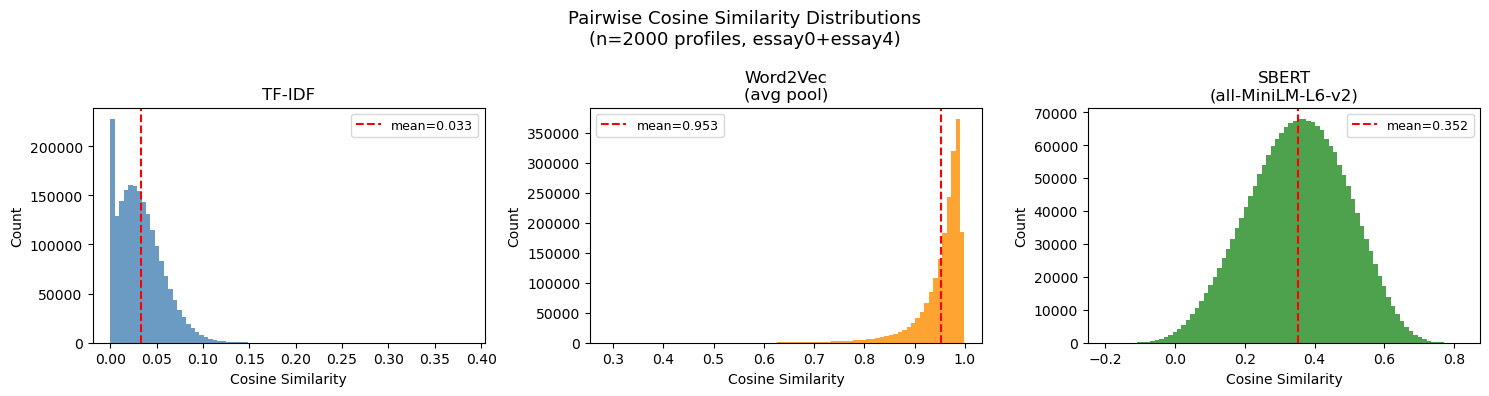

Saved: similarity_distributions.png


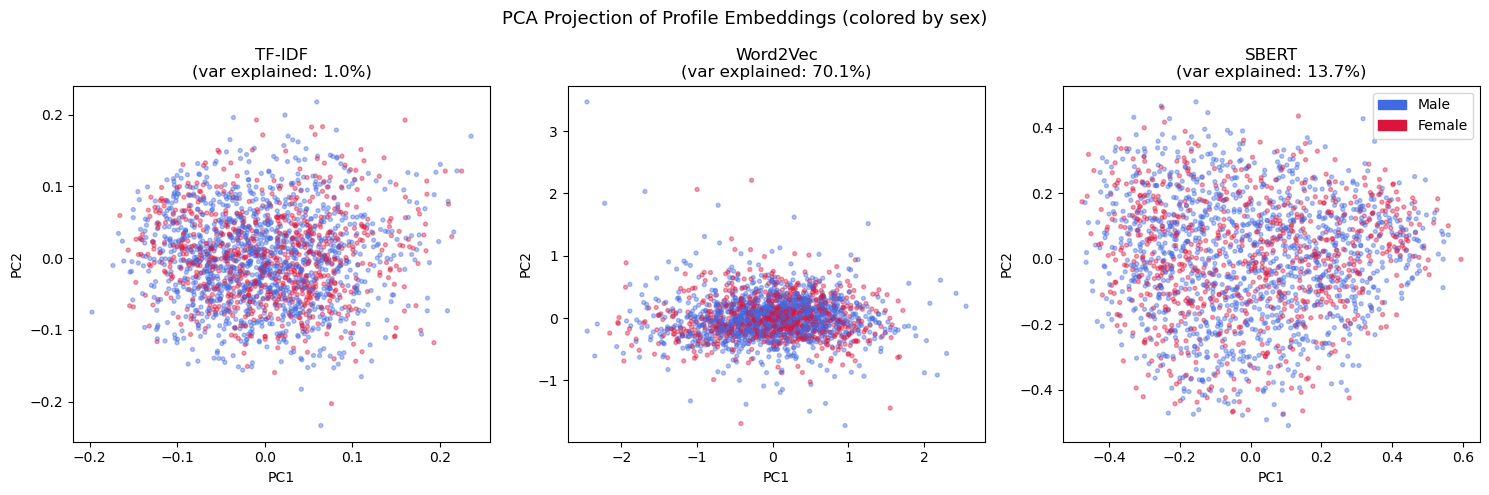

Saved: pca_projections.png

=== TOP-5 MOST SIMILAR PAIRS PER METHOD ===

[TF-IDF]
  Rank 1 (sim=0.3845):
    A: im just on here for friends & nothing more!!!!!!!!!!!!!!!!!!!!!!!!!!!!!...
    B: im half filipino and half white and im trying to live my life to the fullest don't have one...

  Rank 2 (sim=0.3578):
    A: http://www.youtube.com/watch?v=imtdwizwedu http://thefeministwire.com/2012/02/of-ambivalence-the-help-obama-and-the-ulti...
    B: while i was vacationing in japan recently, i met two separate expatriates whose lives were consistently more fun than i ...

  Rank 3 (sim=0.3543):
    A: im just on here for friends & nothing more!!!!!!!!!!!!!!!!!!!!!!!!!!!!!...
    B: im cautious and generous. im open hearted and boundaried. im learning im a terrible dishwasher.  i strive for gracefulne...

  Rank 4 (sim=0.3531):
    A: some have told me that this video is me at my best. i hope so. it's certainly me doing what i love to do the most - sell...
    B: http://www.youtube.com/wat

In [9]:
# after loading data, Combine essay0 + essay4; fill missing with empty string
okCupid['profile_text'] = (
    okCupid['essay0'].fillna('') + ' ' + okCupid['essay4'].fillna('')
).str.strip()

# Drop rows where both essays were empty
okCupid = okCupid[okCupid['profile_text'].str.len() > 50].reset_index(drop=True)
print(f"Profiles with usable text: {len(okCupid)}")

# Sample 2000 profiles for pairwise experiments (full 60k = 3.6B pairs)
SAMPLE_N = 2000
RANDOM_SEED = 42
sample = okCupid.sample(SAMPLE_N, random_state=RANDOM_SEED).reset_index(drop=True)
texts = sample['profile_text'].tolist()
print(f"Sample size: {len(texts)}")

# ============================================================
# METHOD 1: TF-IDF + Cosine Similarity
# (Lecture 3: Vector Space Model, idf_t = log(N/df_t))
# ============================================================
print("\n--- TF-IDF ---")
tfidf = TfidfVectorizer(max_features=10000, stop_words='english', 
                         min_df=2, sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(texts)  # shape: (2000, vocab)
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# Compute all pairwise cosine similarities (upper triangle only)
tfidf_sims = cosine_similarity(tfidf_matrix)
tfidf_upper = tfidf_sims[np.triu_indices(SAMPLE_N, k=1)]
print(f"TF-IDF similarity — mean: {tfidf_upper.mean():.4f}, std: {tfidf_upper.std():.4f}")

# ============================================================
# METHOD 2: Word2Vec Average Pooling
# (Lecture 4: dense word embeddings, avg pooling as doc vector)
# Install first if needed: pip install gensim
# ============================================================
print("\n--- Word2Vec ---")
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

tokenized = [simple_preprocess(t) for t in texts]

w2v_model = Word2Vec(
    sentences=tokenized,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=RANDOM_SEED
)

def avg_w2v(tokens, model):
    """Average pool word vectors for a document."""
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

w2v_vecs = np.array([avg_w2v(t, w2v_model) for t in tokenized])
print(f"Word2Vec matrix shape: {w2v_vecs.shape}")

w2v_sims = cosine_similarity(w2v_vecs)
w2v_upper = w2v_sims[np.triu_indices(SAMPLE_N, k=1)]
print(f"Word2Vec similarity — mean: {w2v_upper.mean():.4f}, std: {w2v_upper.std():.4f}")

# ============================================================
# METHOD 3: SBERT Sentence Embeddings (GPU accelerated)
# (Lecture 10: pretrain-finetune paradigm; SBERT fine-tunes
#  BERT with a siamese network + cosine similarity objective)
# Install: pip install sentence-transformers
# ============================================================
print("\n--- SBERT ---")

from sentence_transformers import SentenceTransformer

sbert_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# Encode in batches — GPU will handle this fast
sbert_vecs = sbert_model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(f"SBERT matrix shape: {sbert_vecs.shape}")

sbert_sims = cosine_similarity(sbert_vecs)
sbert_upper = sbert_sims[np.triu_indices(SAMPLE_N, k=1)]
print(f"SBERT similarity — mean: {sbert_upper.mean():.4f}, std: {sbert_upper.std():.4f}")

# ============================================================
# VISUALIZATION 1: Similarity score distributions
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle('Pairwise Cosine Similarity Distributions\n(n=2000 profiles, essay0+essay4)', 
             fontsize=13)

for ax, sims, label, color in zip(
    axes,
    [tfidf_upper, w2v_upper, sbert_upper],
    ['TF-IDF', 'Word2Vec\n(avg pool)', 'SBERT\n(all-MiniLM-L6-v2)'],
    ['steelblue', 'darkorange', 'forestgreen']
):
    ax.hist(sims, bins=80, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(sims.mean(), color='red', linestyle='--', linewidth=1.5, label=f'mean={sims.mean():.3f}')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Cosine Similarity')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('similarity_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: similarity_distributions.png")

# ============================================================
# VISUALIZATION 2: PCA projection of embeddings (colored by sex)
# (Lecture 6: PCA captures directions of max variance)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('PCA Projection of Profile Embeddings (colored by sex)', fontsize=13)

sex_labels = sample['sex'].values
colors = ['royalblue' if s == 'm' else 'crimson' for s in sex_labels]

for ax, matrix, label in zip(
    axes,
    [tfidf_matrix.toarray(), w2v_vecs, sbert_vecs],
    ['TF-IDF', 'Word2Vec', 'SBERT']
):
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    proj = pca.fit_transform(matrix)
    ax.scatter(proj[:, 0], proj[:, 1], c=colors, alpha=0.4, s=8)
    ax.set_title(f'{label}\n(var explained: {pca.explained_variance_ratio_.sum():.1%})')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='royalblue', label='Male'), Patch(color='crimson', label='Female')]
axes[2].legend(handles=legend, loc='upper right')

plt.tight_layout()
plt.savefig('pca_projections.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pca_projections.png")

# ============================================================
# VISUALIZATION 3: Top-5 most similar profile pairs per method
# (qualitative sanity check)
# ============================================================
print("\n=== TOP-5 MOST SIMILAR PAIRS PER METHOD ===")

def top_k_pairs(sim_matrix, texts, k=5):
    # Zero out diagonal and lower triangle
    upper = np.triu(sim_matrix, k=1)
    flat_idx = np.argsort(upper.ravel())[::-1][:k]
    rows, cols = np.unravel_index(flat_idx, upper.shape)
    for rank, (i, j) in enumerate(zip(rows, cols)):
        print(f"  Rank {rank+1} (sim={upper[i,j]:.4f}):")
        print(f"    A: {texts[i][:120]}...")
        print(f"    B: {texts[j][:120]}...")
        print()

for method, matrix in [('TF-IDF', tfidf_sims), 
                        ('Word2Vec', w2v_sims), 
                        ('SBERT', sbert_sims)]:
    print(f"\n[{method}]")
    top_k_pairs(matrix, texts)

# ============================================================
# SUMMARY TABLE
# ============================================================
summary = pd.DataFrame({
    'Method': ['TF-IDF', 'Word2Vec (avg)', 'SBERT (MiniLM)'],
    'Embedding Dim': [tfidf_matrix.shape[1], w2v_vecs.shape[1], sbert_vecs.shape[1]],
    'Mean Sim': [tfidf_upper.mean(), w2v_upper.mean(), sbert_upper.mean()],
    'Std Sim':  [tfidf_upper.std(),  w2v_upper.std(),  sbert_upper.std()],
    'Max Sim':  [tfidf_upper.max(),  w2v_upper.max(),  sbert_upper.max()],
})
print("\n=== SUMMARY ===")
print(summary.to_string(index=False))
summary.to_csv('experiment_a_summary.csv', index=False)

## Experiment B: Attribute Compatibility

Builds pseudo-label benchmark and trains both simple basline & softscore version


Single profiles: 51414
Building pairs and computing labels...
Pairs built: 10000
Baseline label balance: {0: 0.5305, 1: 0.4695}
Soft label balance:     {1: 0.6222, 0: 0.3778}

--- Logistic Regression (Baseline labels) ---
AUC (baseline): 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1061
           1       1.00      1.00      1.00       939

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


--- Gradient Boosting (Soft labels) ---
AUC (soft): 0.9560
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       756
           1       0.89      0.91      0.90      1244

    accuracy                           0.87      2000
   macro avg       0.87      0.86      0.87      2000
weighted avg       0.87      0.87      0.87      2000



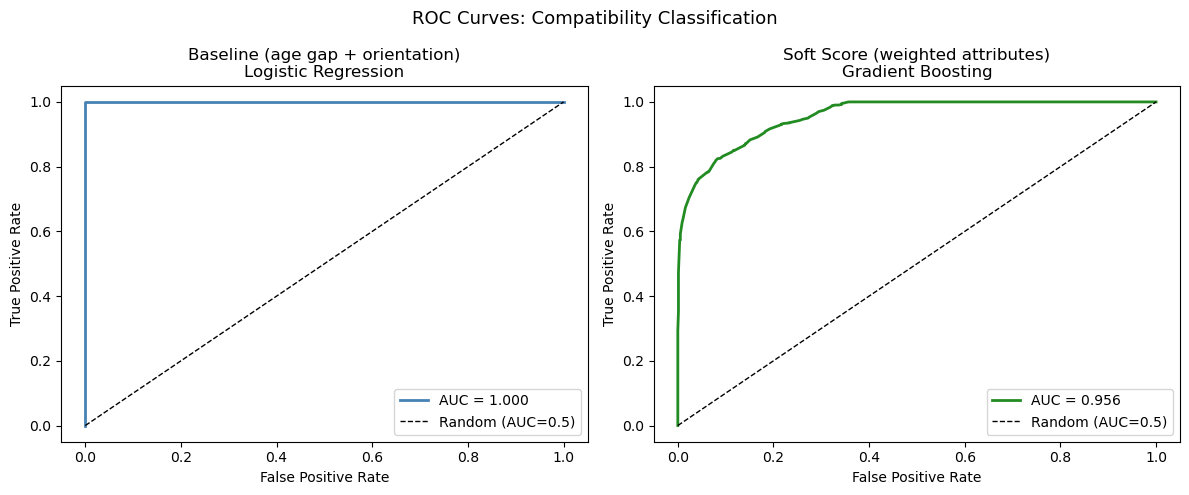

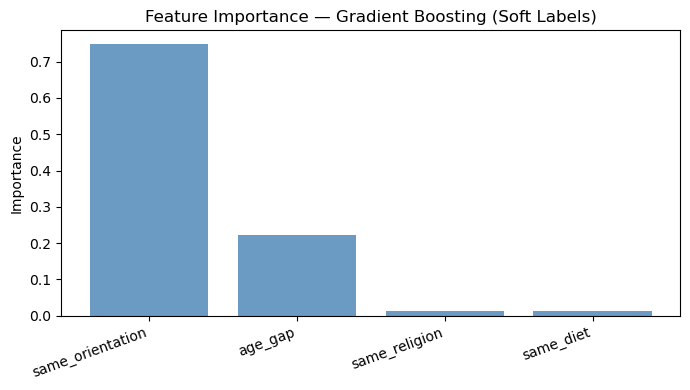

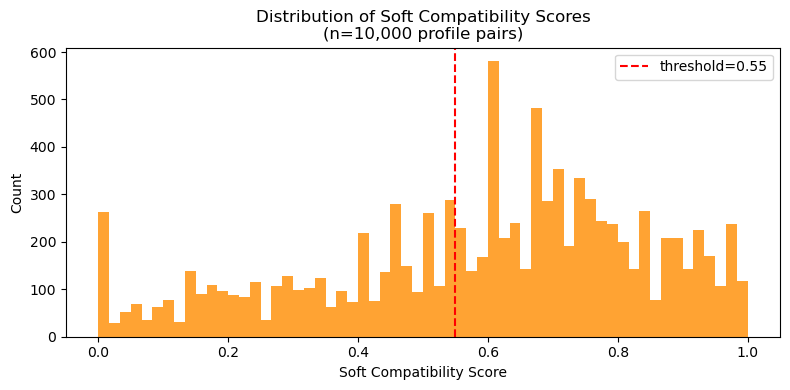

In [10]:
# ============================================================
# EXPERIMENT B: Attribute-Based Compatibility Scoring
# Baseline (age gap + orientation) → Soft (weighted attributes)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

okCupid = okCupid[okCupid['status'] == 'single'].reset_index(drop=True)
print(f"Single profiles: {len(okCupid)}")

# Clean income (-1 = not disclosed → NaN)
okCupid['income'] = okCupid['income'].replace(-1, np.nan)

# ============================================================
# PSEUDO-LABEL CONSTRUCTION
# ============================================================

# --- BASELINE: age gap + orientation match ---
def baseline_compatible(r1, r2):
    """Simple rule: same orientation, age gap <= 10 years."""
    age_ok = abs(r1['age'] - r2['age']) <= 10
    orient_ok = r1['orientation'] == r2['orientation']
    return int(age_ok and orient_ok)

# --- SOFT SCORE: weighted attribute agreement ---
def soft_score(r1, r2):
    """
    Weighted compatibility across multiple attributes.
    Returns a float in [0, 1].
    """
    score = 0.0
    total_weight = 0.0

    # Age gap (weight=2): score decays linearly up to 15yr gap
    w = 2.0
    age_gap = abs(r1['age'] - r2['age'])
    score += w * max(0, 1 - age_gap / 15)
    total_weight += w

    # Orientation match (weight=3): hard requirement
    w = 3.0
    if pd.notna(r1['orientation']) and pd.notna(r2['orientation']):
        score += w * int(r1['orientation'] == r2['orientation'])
        total_weight += w

    # Religion (weight=1.5): exact match
    w = 1.5
    if pd.notna(r1['religion']) and pd.notna(r2['religion']):
        # Normalize: strip qualifiers like "but not too serious about it"
        rel1 = r1['religion'].split(' and ')[0].split(' but ')[0].strip()
        rel2 = r2['religion'].split(' and ')[0].split(' but ')[0].strip()
        score += w * int(rel1 == rel2)
        total_weight += w

    # Diet (weight=1): exact match
    w = 1.0
    if pd.notna(r1['diet']) and pd.notna(r2['diet']):
        diet1 = r1['diet'].replace('strictly ', '').replace('mostly ', '').strip()
        diet2 = r2['diet'].replace('strictly ', '').replace('mostly ', '').strip()
        score += w * int(diet1 == diet2)
        total_weight += w

    # Education level (weight=1): within 1 level
    edu_order = {
        'graduated from high school': 1,
        'working on college/university': 2,
        'graduated from college/university': 3,
        'working on masters program': 4,
        'graduated from masters program': 5,
        'working on ph.d program': 6,
        'graduated from ph.d program': 7,
        'graduated from law school': 6,
        'graduated from med school': 6,
        'working on space camp': 2,  # joke answer
    }
    w = 1.0
    e1 = edu_order.get(r1.get('education', ''), None)
    e2 = edu_order.get(r2.get('education', ''), None)
    if e1 and e2:
        score += w * max(0, 1 - abs(e1 - e2) / 3)
        total_weight += w

    return score / total_weight if total_weight > 0 else 0.0

# ============================================================
# SAMPLE PAIRS (stratified: ~50% compatible)
# ============================================================
SAMPLE_N = 3000  # profiles to sample from
N_PAIRS = 10000  # pairs to evaluate

sample = okCupid.sample(SAMPLE_N, random_state=RANDOM_SEED).reset_index(drop=True)

print("Building pairs and computing labels...")
pairs = []
for _ in range(N_PAIRS * 3):  # oversample to hit target
    i, j = np.random.choice(SAMPLE_N, 2, replace=False)
    r1, r2 = sample.iloc[i], sample.iloc[j]
    
    baseline_label = baseline_compatible(r1, r2)
    soft = soft_score(r1, r2)
    soft_label = int(soft >= 0.55)  # threshold at 55th percentile
    
    pairs.append({
        'i': i, 'j': j,
        'age_i': r1['age'], 'age_j': r2['age'],
        'age_gap': abs(r1['age'] - r2['age']),
        'same_orientation': int(r1['orientation'] == r2['orientation']),
        'same_religion': int(
            pd.notna(r1['religion']) and pd.notna(r2['religion']) and
            r1['religion'].split(' but ')[0] == r2['religion'].split(' but ')[0]
        ),
        'same_diet': int(
            pd.notna(r1['diet']) and pd.notna(r2['diet']) and
            r1['diet'].replace('strictly','').replace('mostly','').strip() ==
            r2['diet'].replace('strictly','').replace('mostly','').strip()
        ),
        'soft_score': soft,
        'baseline_label': baseline_label,
        'soft_label': soft_label,
    })

pairs_df = pd.DataFrame(pairs).drop_duplicates(subset=['i','j']).head(N_PAIRS)
print(f"Pairs built: {len(pairs_df)}")
print(f"Baseline label balance: {pairs_df['baseline_label'].value_counts(normalize=True).to_dict()}")
print(f"Soft label balance:     {pairs_df['soft_label'].value_counts(normalize=True).to_dict()}")

# ============================================================
# FEATURE MATRIX
# ============================================================
feature_cols = ['age_gap', 'same_orientation', 'same_religion', 'same_diet']
X = pairs_df[feature_cols].values

# ============================================================
# MODEL A: Logistic Regression on BASELINE labels
# ============================================================
print("\n--- Logistic Regression (Baseline labels) ---")
y_base = pairs_df['baseline_label'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y_base, test_size=0.2, random_state=RANDOM_SEED, stratify=y_base)

lr_base = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_base.fit(X_train, y_train)
y_prob_base = lr_base.predict_proba(X_test)[:, 1]
print(f"AUC (baseline): {roc_auc_score(y_test, y_prob_base):.4f}")
print(classification_report(y_test, lr_base.predict(X_test)))

# ============================================================
# MODEL B: Gradient Boosting on SOFT labels
# ============================================================
print("\n--- Gradient Boosting (Soft labels) ---")
y_soft = pairs_df['soft_label'].values
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_soft, test_size=0.2, random_state=RANDOM_SEED, stratify=y_soft)

gb_soft = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05, random_state=RANDOM_SEED)
gb_soft.fit(X_train_s, y_train_s)
y_prob_soft = gb_soft.predict_proba(X_test_s)[:, 1]
print(f"AUC (soft): {roc_auc_score(y_test_s, y_prob_soft):.4f}")
print(classification_report(y_test_s, gb_soft.predict(X_test_s)))

# ============================================================
# VISUALIZATION 1: ROC curves comparison
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('ROC Curves: Compatibility Classification', fontsize=13)

for ax, y_t, y_p, title, color in zip(
    axes,
    [y_test, y_test_s],
    [y_prob_base, y_prob_soft],
    ['Baseline (age gap + orientation)\nLogistic Regression',
     'Soft Score (weighted attributes)\nGradient Boosting'],
    ['steelblue', 'forestgreen']
):
    fpr, tpr, _ = roc_curve(y_t, y_p)
    auc = roc_auc_score(y_t, y_p)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc:.3f}')
    ax.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.5)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# VISUALIZATION 2: Feature importance (Gradient Boosting)
# ============================================================
fig, ax = plt.subplots(figsize=(7, 4))
importances = gb_soft.feature_importances_
idx = np.argsort(importances)[::-1]
ax.bar(range(len(feature_cols)), importances[idx], color='steelblue', alpha=0.8)
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels([feature_cols[i] for i in idx], rotation=20, ha='right')
ax.set_title('Feature Importance — Gradient Boosting (Soft Labels)')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# VISUALIZATION 3: Soft score distribution
# ============================================================
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pairs_df['soft_score'], bins=60, color='darkorange', alpha=0.8, edgecolor='none')
ax.axvline(0.55, color='red', linestyle='--', lw=1.5, label='threshold=0.55')
ax.set_xlabel('Soft Compatibility Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Soft Compatibility Scores\n(n=10,000 profile pairs)')
ax.legend()
plt.tight_layout()
plt.savefig('soft_score_dist.png', dpi=150, bbox_inches='tight')
plt.show()


Using device: cuda


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 16522.07it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Labels: {0: 'negative', 1: 'neutral', 2: 'positive'}
Sentiment sample size: 2000


Encoding sentiment: 100%|██████████| 63/63 [00:28<00:00,  2.18it/s]


Affect vectors shape: (2000, 3)


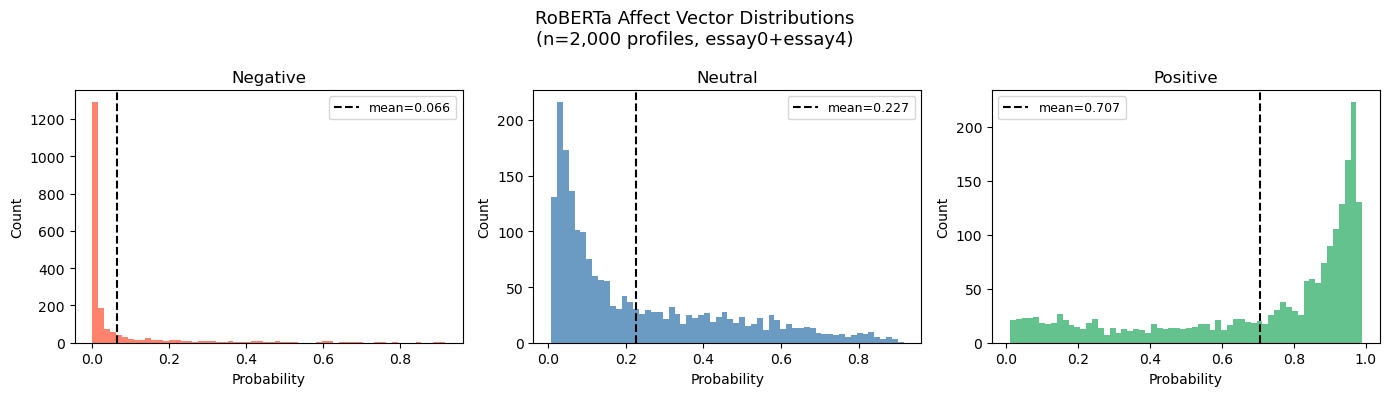

Saved: affect_distributions.png

Affect vector summary:
        neg_prob   neu_prob   pos_prob
count  2000.0000  2000.0000  2000.0000
mean      0.0656     0.2273     0.7071
std       0.1453     0.2217     0.3016
min       0.0013     0.0071     0.0098
25%       0.0043     0.0492     0.5187
50%       0.0087     0.1314     0.8545
75%       0.0343     0.3654     0.9445
max       0.9164     0.9164     0.9911


In [11]:
# ============================================================
# STEP 1: RoBERTa Sentiment — Per-Profile Affect Vectors
# Model: cardiffnlp/twitter-roberta-base-sentiment-latest
# Outputs a 3D vector [negative, neutral, positive] per profile.
# We use the full 3-vector (not a scalar) because downstream
# compatibility benefits from matching emotional *registers*
# — e.g., both high-positive vs. one cynical — which a scalar
# collapses. Cosine similarity between two affect vectors is
# used as the sentiment_sim feature in the re-ranker.
# ============================================================

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm import tqdm

RANDOM_SEED_STEP12 = 123   # fresh held-out draw, distinct from Exp A (42) and B (42)
SENTIMENT_N        = 2000  # profiles for sentiment encoding
BATCH_SIZE         = 32    # safe for 4GB VRAM with roberta-base

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Load model ──────────────────────────────────────────────
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
sent_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
sent_model.eval()
print(f"Labels: {sent_model.config.id2label}")
# Expected: {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

# ── Sample a fresh held-out set ──────────────────────────────
# okCupid already has 'profile_text' from Cell 11.
# We re-sample with a different seed so this set doesn't overlap
# with the Exp A (seed=42, n=2000) sample in expectation.
sentiment_sample = (
    okCupid[okCupid['profile_text'].str.len() > 50]
    .sample(SENTIMENT_N, random_state=RANDOM_SEED_STEP12)
    .reset_index(drop=True)
)
texts_sent = sentiment_sample['profile_text'].tolist()
print(f"Sentiment sample size: {len(texts_sent)}")

# ── Batch inference ──────────────────────────────────────────
def get_affect_vectors(texts, tokenizer, model, batch_size, device):
    """
    Returns numpy array of shape (N, 3): [neg_prob, neu_prob, pos_prob]
    Truncates each text to 128 tokens — sufficient for short profiles
    and keeps memory well within 4GB VRAM.
    """
    all_probs = []
    for start in tqdm(range(0, len(texts), batch_size), desc="Encoding sentiment"):
        batch = texts[start : start + batch_size]
        enc = tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            max_length=128,
            padding=True
        ).to(device)
        with torch.no_grad():
            logits = model(**enc).logits          # (B, 3)
        probs = F.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs)
    return np.vstack(all_probs)  # (N, 3)

affect_vecs = get_affect_vectors(texts_sent, tokenizer, sent_model, BATCH_SIZE, device)
print(f"Affect vectors shape: {affect_vecs.shape}")   # (2000, 3)

# ── Store in dataframe for Step 2 ───────────────────────────
sentiment_sample['neg_prob'] = affect_vecs[:, 0]
sentiment_sample['neu_prob'] = affect_vecs[:, 1]
sentiment_sample['pos_prob'] = affect_vecs[:, 2]

# ── Visualize affect distribution across profiles ────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('RoBERTa Affect Vector Distributions\n(n=2,000 profiles, essay0+essay4)', fontsize=13)

for ax, col, color, label in zip(
    axes,
    ['neg_prob', 'neu_prob', 'pos_prob'],
    ['tomato', 'steelblue', 'mediumseagreen'],
    ['Negative', 'Neutral', 'Positive']
):
    ax.hist(sentiment_sample[col], bins=60, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(sentiment_sample[col].mean(), color='black', linestyle='--', lw=1.5,
               label=f'mean={sentiment_sample[col].mean():.3f}')
    ax.set_title(label)
    ax.set_xlabel('Probability')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('affect_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: affect_distributions.png")

# ── Summary stats ────────────────────────────────────────────
print("\nAffect vector summary:")
print(sentiment_sample[['neg_prob','neu_prob','pos_prob']].describe().round(4).to_string())

### UMAP Visualization of SBERT embeddings

Why UMAP over PCA :

PCA is a linear projection — it finds the 2 directions of 
maximum variance in 384-dimensional space. 

For SBERT embeddings, those top-2 directions only capture ~13.7% of total variance,
meaning 86% of the semantic structure is invisible in the plot.

UMAP (Uniform Manifold Approximation and Projection) is a 
nonlinear manifold technique. 

It builds a graph of nearest neighbors in high-dimensional space and finds a 2D layout that preserves local neighborhood structure

profiles that are semantically close in 384D will appear close in 2D, regardless 
of which linear directions those clusters happen to lie along.

This makes cluster structure visible that PCA would miss entirely.

In [12]:
# ! pip install umap-learn

Computing per-profile mean soft compatibility scores for UMAP coloring...
Mean soft score across profiles: 0.587 ± 0.146
Fitting UMAP on SBERT embeddings
UMAP done.


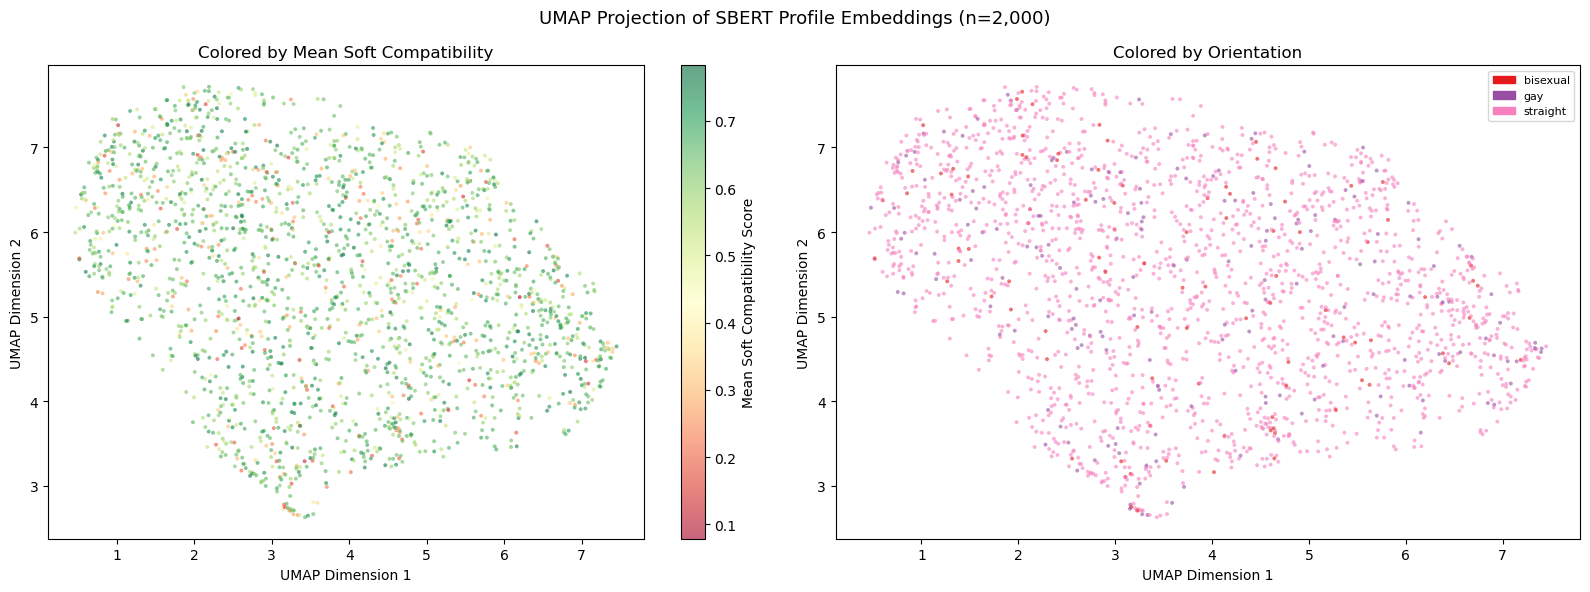

Saved: umap_sbert_embeddings.png


In [13]:
# cluster SBERT embeddings with UMAP plot

import umap

# ── Compute soft compatibility scores for coloring ──────────────────────────
# We want to color each profile by its AVERAGE soft compatibility score
# against all other profiles in the sample. This gives a per-profile 
# "how compatible is this person on average" measure — a useful axis
# for interpreting where clusters fall in UMAP space.
#
# reuse soft_score() function from Experiment B.

# Compute mean soft score per profile against a random subset of others
# (computing all 2M pairs is slow; 200 random partners per profile is enough
#  to get a stable mean — law of large numbers)
print("Computing per-profile mean soft compatibility scores for UMAP coloring...")

SCORE_PARTNERS = 200  # how many random profiles to score each profile against
rng = np.random.default_rng(42)
N = sbert_vecs.shape[0]
mean_soft_scores = np.zeros(N)

# for i in range(SAMPLE_N):
#     partner_idxs = rng.choice(
#         [j for j in range(SAMPLE_N) if j != i], 
#         size=SCORE_PARTNERS, 
#         replace=False
#     )
#     scores = [soft_score(sample.iloc[i], sample.iloc[j]) for j in partner_idxs]
#     mean_soft_scores[i] = np.mean(scores)

# this is faster list comprehension approach (i think)
all_indices = np.arange(N)
for i in range(N):
    partner_idxs = rng.choice(
        all_indices[all_indices != i],
        size=SCORE_PARTNERS,
        replace=False
    )
    scores = [soft_score(sample.iloc[i], sample.iloc[j]) for j in partner_idxs]
    mean_soft_scores[i] = np.mean(scores)

print(f"Mean soft score across profiles: {mean_soft_scores.mean():.3f} ± {mean_soft_scores.std():.3f}")


# ── Fit UMAP ────────────────────────────────────────────────────────────────
# Key hyperparameters:
#   n_neighbors: controls local vs global structure tradeoff.
#     Lower = tighter local clusters, higher = more global layout.
#     15 is a standard default for semantic embeddings.
#   min_dist: minimum distance between points in 2D output.
#     Lower = tighter packing (more cluster separation visible).
#     0.05 works well for showing cluster structure.
#   metric: cosine is correct here because SBERT embeddings are
#     trained with cosine similarity as the distance measure.

print("Fitting UMAP on SBERT embeddings")
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.05,
    n_components=2,
    metric='cosine',
    random_state=42
)
umap_proj = reducer.fit_transform(sbert_vecs)  # shape: (2000, 2)
print("UMAP done.")


# ── Plot 1: colored by mean soft compatibility score ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('UMAP Projection of SBERT Profile Embeddings (n=2,000)', fontsize=13)

# Left panel: color by mean soft compatibility score
sc = axes[0].scatter(
    umap_proj[:, 0], umap_proj[:, 1],
    c=mean_soft_scores,
    cmap='RdYlGn',       # red=low compatibility, green=high compatibility
    alpha=0.6,
    s=8,
    linewidths=0
)
plt.colorbar(sc, ax=axes[0], label='Mean Soft Compatibility Score')
axes[0].set_title('Colored by Mean Soft Compatibility')
axes[0].set_xlabel('UMAP Dimension 1')
axes[0].set_ylabel('UMAP Dimension 2')

# Right panel: color by orientation
# This lets you visually inspect whether SBERT clusters correspond 
# to orientation groups — we expect some separation since orientation
# correlates with how people write about themselves
orientation_vals = sample.iloc[:N]['orientation'].fillna('unknown').values
unique_orientations = sorted(set(orientation_vals))
orient_palette = plt.cm.Set1(np.linspace(0, 0.8, len(unique_orientations)))
orient_color_map = {o: orient_palette[i] for i, o in enumerate(unique_orientations)}
orient_colors = [orient_color_map[o] for o in orientation_vals]

axes[1].scatter(
    umap_proj[:, 0], umap_proj[:, 1],
    c=orient_colors,
    alpha=0.6,
    s=8,
    linewidths=0
)
axes[1].set_title('Colored by Orientation')
axes[1].set_xlabel('UMAP Dimension 1')
axes[1].set_ylabel('UMAP Dimension 2')

# Add legend for orientation
from matplotlib.patches import Patch
legend_handles = [Patch(color=orient_color_map[o], label=o) for o in unique_orientations]
axes[1].legend(handles=legend_handles, loc='upper right', fontsize=8, markerscale=2)

plt.tight_layout()
plt.savefig('umap_sbert_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: umap_sbert_embeddings.png")

Encoding held-out profiles with SBERT...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3646.11it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 32/32 [00:07<00:00,  4.15it/s]


SBERT vecs shape: (2000, 384)
Pairs after removing self-pairs: 4996

=== Cross-Signal Correlation Results ===
SBERT sim vs. soft compatibility:
  Pearson  r = 0.0206  (p=1.4549e-01)
  Spearman r = 0.0207  (p=1.4346e-01)

Sentiment sim vs. soft compatibility:
  Pearson  r = 0.0036  (p=8.0168e-01)
  Spearman r = 0.0075  (p=5.9491e-01)


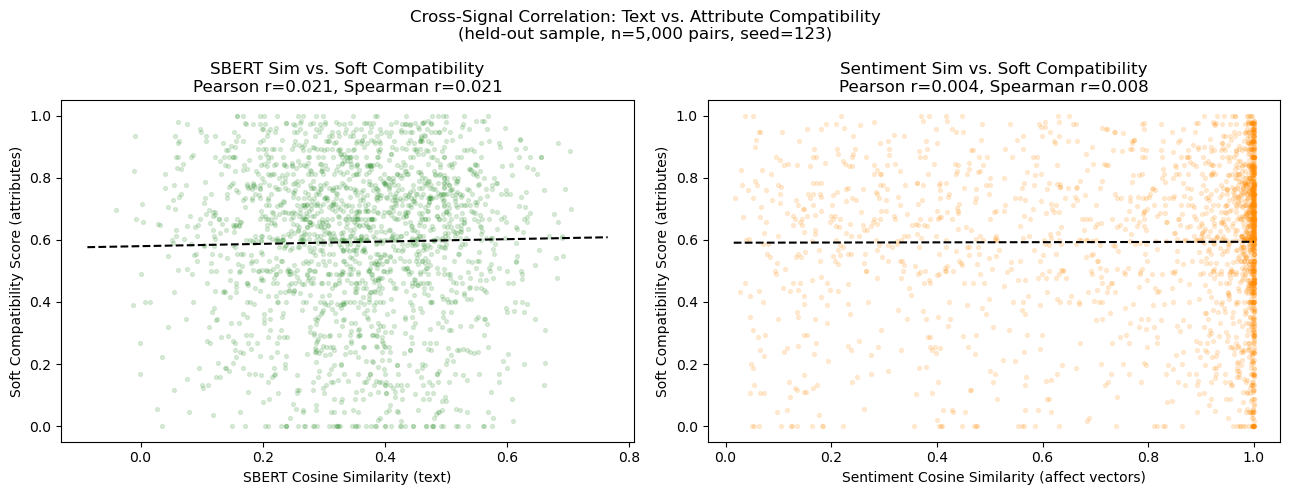

Saved: cross_signal_correlation.png


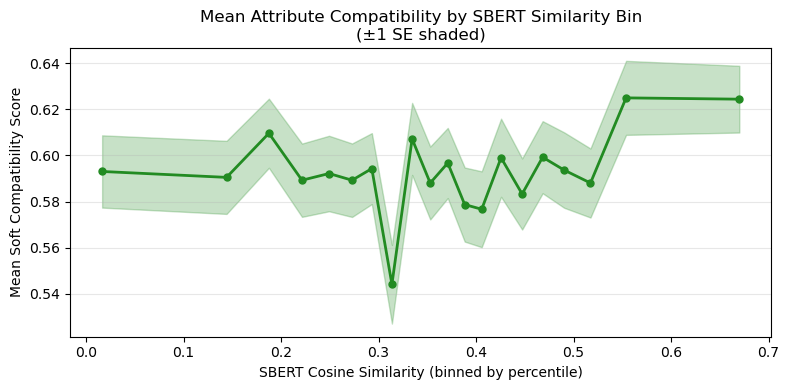

Saved: binned_correlation.png

=== Correlation Summary ===
                Signal Pair  Pearson r Pearson p  Spearman r Spearman p
    SBERT sim → soft compat     0.0206  1.45e-01      0.0207   1.43e-01
Sentiment sim → soft compat     0.0036  8.02e-01      0.0075   5.95e-01


In [14]:
# ============================================================
# STEP 2: Cross-Signal Correlation
# SBERT pairwise similarity vs. soft compatibility score
# on the SAME held-out pairs (seed=123).
#
# Core question: are semantically similar profiles (by text)
# also attribute-compatible? If yes → text + attributes are
# redundant. If weak/no correlation → they capture orthogonal
# signals, which motivates hybrid fusion.
# ============================================================

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
from scipy.stats import pearsonr, spearmanr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

N_PAIRS_STEP2 = 5000   # pairs to sample from the 2000-profile held-out set

# ── Re-use sentiment_sample (seed=123, n=2000) ───────────────
# This is our held-out set for both signals.

# ── 2a: SBERT embeddings on the held-out set ─────────────────
print("Encoding held-out profiles with SBERT...")
sbert_model_s2 = SentenceTransformer('all-MiniLM-L6-v2', device=device)

sbert_vecs_s2 = sbert_model_s2.encode(
    texts_sent,          # same 2000 profiles as affect_vecs
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(f"SBERT vecs shape: {sbert_vecs_s2.shape}")   # (2000, 384)

# ── 2b: Sample random pairs and compute both signals ─────────
rng = np.random.default_rng(RANDOM_SEED_STEP12)
idx_i = rng.integers(0, SENTIMENT_N, size=N_PAIRS_STEP2)
idx_j = rng.integers(0, SENTIMENT_N, size=N_PAIRS_STEP2)

# Remove self-pairs
mask = idx_i != idx_j
idx_i, idx_j = idx_i[mask], idx_j[mask]
idx_i, idx_j = idx_i[:N_PAIRS_STEP2], idx_j[:N_PAIRS_STEP2]
print(f"Pairs after removing self-pairs: {len(idx_i)}")

# ── SBERT cosine similarity per pair ─────────────────────────
sbert_pair_sims = np.array([
    cos_sim(sbert_vecs_s2[i].reshape(1, -1),
            sbert_vecs_s2[j].reshape(1, -1))[0, 0]
    for i, j in zip(idx_i, idx_j)
])

# ── Soft compatibility score per pair ─────────────────────────
# Reuse the soft_score() function defined in Experiment B (Cell 13).
rows = sentiment_sample  # the 2000-profile dataframe

soft_scores_s2 = np.array([
    soft_score(rows.iloc[i], rows.iloc[j])
    for i, j in zip(idx_i, idx_j)
])

# ── Sentiment cosine similarity per pair ─────────────────────
# Cosine similarity between two 3D affect vectors.
affect_pair_sims = np.array([
    cos_sim(affect_vecs[i].reshape(1, -1),
            affect_vecs[j].reshape(1, -1))[0, 0]
    for i, j in zip(idx_i, idx_j)
])

# ── Correlation analysis ──────────────────────────────────────
r_pearson,  p_pearson  = pearsonr(sbert_pair_sims,   soft_scores_s2)
r_spearman, p_spearman = spearmanr(sbert_pair_sims,  soft_scores_s2)
r_sent_p,   p_sent_p   = pearsonr(affect_pair_sims,  soft_scores_s2)
r_sent_s,   p_sent_s   = spearmanr(affect_pair_sims, soft_scores_s2)

print("\n=== Cross-Signal Correlation Results ===")
print(f"SBERT sim vs. soft compatibility:")
print(f"  Pearson  r = {r_pearson:.4f}  (p={p_pearson:.4e})")
print(f"  Spearman r = {r_spearman:.4f}  (p={p_spearman:.4e})")
print(f"\nSentiment sim vs. soft compatibility:")
print(f"  Pearson  r = {r_sent_p:.4f}  (p={p_sent_p:.4e})")
print(f"  Spearman r = {r_sent_s:.4f}  (p={p_sent_s:.4e})")

# ── Visualization 1: Scatter — SBERT sim vs. soft score ──────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Cross-Signal Correlation: Text vs. Attribute Compatibility\n(held-out sample, n=5,000 pairs, seed=123)', fontsize=12)

# Subsample for scatter readability
plot_n = 2000
rng2 = np.random.default_rng(0)
plot_idx = rng2.choice(len(sbert_pair_sims), size=plot_n, replace=False)

ax = axes[0]
ax.scatter(
    sbert_pair_sims[plot_idx], soft_scores_s2[plot_idx],
    alpha=0.15, s=8, color='forestgreen'
)
# Trend line
m, b = np.polyfit(sbert_pair_sims, soft_scores_s2, 1)
xs = np.linspace(sbert_pair_sims.min(), sbert_pair_sims.max(), 100)
ax.plot(xs, m * xs + b, color='black', lw=1.5, linestyle='--')
ax.set_xlabel('SBERT Cosine Similarity (text)')
ax.set_ylabel('Soft Compatibility Score (attributes)')
ax.set_title(f'SBERT Sim vs. Soft Compatibility\nPearson r={r_pearson:.3f}, Spearman r={r_spearman:.3f}')

ax = axes[1]
ax.scatter(
    affect_pair_sims[plot_idx], soft_scores_s2[plot_idx],
    alpha=0.15, s=8, color='darkorange'
)
m2, b2 = np.polyfit(affect_pair_sims, soft_scores_s2, 1)
xs2 = np.linspace(affect_pair_sims.min(), affect_pair_sims.max(), 100)
ax.plot(xs2, m2 * xs2 + b2, color='black', lw=1.5, linestyle='--')
ax.set_xlabel('Sentiment Cosine Similarity (affect vectors)')
ax.set_ylabel('Soft Compatibility Score (attributes)')
ax.set_title(f'Sentiment Sim vs. Soft Compatibility\nPearson r={r_sent_p:.3f}, Spearman r={r_sent_s:.3f}')

plt.tight_layout()
plt.savefig('cross_signal_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cross_signal_correlation.png")

# ── Visualization 2: Binned SBERT sim → mean soft score ──────
# Cleaner way to see any monotonic relationship even if noisy.
fig, ax = plt.subplots(figsize=(8, 4))

n_bins = 20
bins = np.percentile(sbert_pair_sims, np.linspace(0, 100, n_bins + 1))
bin_idx = np.digitize(sbert_pair_sims, bins) - 1
bin_idx = np.clip(bin_idx, 0, n_bins - 1)

bin_means  = [soft_scores_s2[bin_idx == k].mean()  for k in range(n_bins)]
bin_sems   = [soft_scores_s2[bin_idx == k].std() /
              np.sqrt((bin_idx == k).sum() + 1e-8)  for k in range(n_bins)]
bin_centers = [(bins[k] + bins[k+1]) / 2 for k in range(n_bins)]

ax.plot(bin_centers, bin_means, 'o-', color='forestgreen', lw=2, ms=5)
ax.fill_between(bin_centers,
                np.array(bin_means) - np.array(bin_sems),
                np.array(bin_means) + np.array(bin_sems),
                alpha=0.25, color='forestgreen')
ax.set_xlabel('SBERT Cosine Similarity (binned by percentile)')
ax.set_ylabel('Mean Soft Compatibility Score')
ax.set_title('Mean Attribute Compatibility by SBERT Similarity Bin\n(±1 SE shaded)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('binned_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: binned_correlation.png")

# ── Correlation summary table ─────────────────────────────────
corr_summary = pd.DataFrame({
    'Signal Pair': [
        'SBERT sim → soft compat',
        'Sentiment sim → soft compat'
    ],
    'Pearson r':  [round(r_pearson, 4),  round(r_sent_p, 4)],
    'Pearson p':  [f'{p_pearson:.2e}',   f'{p_sent_p:.2e}'],
    'Spearman r': [round(r_spearman, 4), round(r_sent_s, 4)],
    'Spearman p': [f'{p_spearman:.2e}',  f'{p_sent_s:.2e}'],
})
print("\n=== Correlation Summary ===")
print(corr_summary.to_string(index=False))
corr_summary.to_csv('cross_signal_correlation_summary.csv', index=False)

## Light FM with NLP Side Features

What LightFM is doing and why:

Standard collaborative filtering learns from interaction data alone (who liked whom). 

New users with no history get nothing (cold-start problem.)

LightFM solves this by incorporating per-profile side features (SBERT embeddings + affect vectors) directly
into the factorization. 

Even a brand-new user gets a meaningful embedding derived from their profile content.

We simulate interactions from soft compatibility scores:

pairs above threshold=0.55 get a "like". This is the proxy for real interaction data.

WARP loss (Weighted Approximate-Rank Pairwise) is used because we care about ranking
pushing compatible profiles to the top of recommendations vs just binary classification.

In [17]:
#! conda install -c conda-forge lightfm

# TODO: installing LightFm is being a pita... try using docker for compatability & run an env within docker image
# if it doesn't work just abandon and go straight to XGBoost reranker for final compatability scores

# Note: LightFM is not included atm bc of several build issues linked in their GitHub repo that have yet to be resolved.
# This was too complex & outside the scope of this project and is ommitted for this reason

In [20]:
# from lightfm import LightFM
# from lightfm.data import Dataset
# from lightfm.evaluation import precision_at_k, auc_score
# import scipy.sparse as sp
# import numpy as np
# import pandas as pd
# from sklearn.metrics.pairwise import cosine_similarity

# RANDOM_SEED_LFM = 42
# np.random.seed(RANDOM_SEED_LFM)

# # ── Re-use the 2000-profile sample from Experiment A ────────
# # 'sample' is your 2000-profile dataframe (seed=42)
# # 'sbert_vecs' is the (2000, 384) SBERT embedding matrix
# # 'affect_vecs' is the (2000, 3) RoBERTa affect vector matrix
# # Both should already be in memory. If not, re-encode using
# # the same code blocks from Steps 1 and Experiment A.

# # ============================================================
# # STAGE 1: Orientation-Compatible Pair Filter
# #
# # Why filter first:
# #   Without filtering, we'd simulate likes between profiles
# #   that would never realistically match (e.g. a straight man
# #   and a gay man). This inflates the interaction matrix with
# #   implausible pairs and gives LightFM a misleading signal.
# #
# # Rules:
# #   straight -> compatible with opposite sex only
# #   gay/lesbian -> compatible with same sex only
# #   bisexual -> compatible with either sex
# # ============================================================

def orientation_compatible(r1, r2):
    """
    Returns True if two profiles could plausibly match
    based on sexual orientation and sex.
    Mirrors the logic of real dating app filtering.
    """
    o1 = str(r1.get('orientation', '')).lower().strip()
    o2 = str(r2.get('orientation', '')).lower().strip()
    s1 = str(r1.get('sex', '')).lower().strip()
    s2 = str(r2.get('sex', '')).lower().strip()

    # If either field is missing, allow the pair (conservative fallback)
    if not o1 or not o2 or not s1 or not s2:
        return True

    # Bisexual profiles are compatible with anyone
    if o1 == 'bisexual' or o2 == 'bisexual':
        return True

    # Gay/lesbian -> same sex required
    if o1 in ('gay', 'lesbian') and o2 in ('gay', 'lesbian'):
        return s1 == s2

    # Straight -> opposite sex required
    if o1 == 'straight' and o2 == 'straight':
        return s1 != s2

    # Mixed (one straight, one gay) -> not compatible
    return False

# # Quick sanity check on orientation distribution in your sample
# print("Orientation distribution in sample:")
# print(sample['orientation'].value_counts())
# print("\nSex distribution in sample:")
# print(sample['sex'].value_counts())


# # ============================================================
# # STAGE 2: Build Simulated Interaction Matrix
# #
# # What we're building:
# #   A sparse (2000 x 2000) matrix where entry (i, j) = 1
# #   means profile i "liked" profile j.
# #
# #   We only add a like if:
# #     1. The pair passes the orientation filter
# #     2. Their soft compatibility score >= 0.55
# #
# #   This gives us a sparse, realistic-looking interaction
# #   matrix that LightFM can learn from.
# #
# # Why sparse:
# #   Real dating apps are extremely sparse — a user swipes
# #   on a tiny fraction of available profiles. Dense matrices
# #   would give LightFM nothing meaningful to learn.
# # ============================================================

# print("\nBuilding orientation-filtered interaction matrix...")
# print("(This computes soft scores for compatible pairs only)")

# # We'll store interactions as a list of (user_id, item_id) tuples
# interactions = []
# soft_scores_lfm = {}  # store per-pair scores for XGBoost later

# COMPAT_THRESHOLD = 0.55

# for i in range(SAMPLE_N):
#     for j in range(SAMPLE_N):
#         if i == j:
#             continue
        
#         r1 = sample.iloc[i]
#         r2 = sample.iloc[j]
        
#         # Stage 1: orientation filter (cheap check first)
#         if not orientation_compatible(r1, r2):
#             continue
        
#         # Stage 2: soft score (only for compatible pairs)
#         score = soft_score(r1, r2)
#         soft_scores_lfm[(i, j)] = score
        
#         # Simulate a "like" if score above threshold
#         if score >= COMPAT_THRESHOLD:
#             interactions.append((i, j))

# n_compatible = len(soft_scores_lfm)
# n_likes = len(interactions)
# print(f"Compatible pairs (passed orientation filter): {n_compatible:,}")
# print(f"Simulated likes (soft score >= {COMPAT_THRESHOLD}): {n_likes:,}")
# print(f"Like rate among compatible pairs: {n_likes/n_compatible:.3f}")
# print(f"Interaction matrix sparsity: {1 - n_likes/(SAMPLE_N**2):.4f}")


# # ============================================================
# # STAGE 3: LightFM Dataset Setup
# #
# # LightFM uses its own Dataset class to manage the mapping
# # between your raw profile indices and its internal ID system.
# # Think of it as a translation layer that also handles the
# # sparse matrix construction for you.
# #
# # We feed in:
# #   - User IDs (profile indices 0..1999) 
# #   - Item IDs (same indices — symmetric matching problem)
# #   - Per-profile feature vectors (SBERT + affect vectors)
# #     These are the "side features" that enable cold-start
# # ============================================================

# dataset = Dataset()

# # Tell LightFM about all user and item IDs
# dataset.fit(
#     users=range(SAMPLE_N),
#     items=range(SAMPLE_N)
# )

# # Build the sparse interaction matrix from simulated likes
# (interaction_matrix, weights) = dataset.build_interactions(interactions)
# print(f"\nInteraction matrix shape: {interaction_matrix.shape}")
# print(f"Stored interactions: {interaction_matrix.nnz}")

# # ── Build per-profile side feature matrix ───────────────────
# # Concatenate SBERT (384-dim) + affect vector (3-dim) = 387-dim
# # per profile. This is what enables cold-start: even with no
# # interaction history, LightFM can represent a profile via its
# # NLP content embedding.
# #
# # LightFM expects side features as a scipy sparse matrix of
# # shape (n_users, n_features). We convert our dense numpy
# # array to sparse format here.

# side_features = np.hstack([sbert_vecs, affect_vecs])  # (2000, 387)
# print(f"Side feature matrix shape: {side_features.shape}")

# # Normalize rows to unit norm — important because LightFM's
# # internal dot products are sensitive to feature scale
# from sklearn.preprocessing import normalize
# side_features_normed = normalize(side_features, norm='l2')

# # Convert to sparse — LightFM's build_user/item_features
# # expects an iterable of (id, feature_dict) tuples OR a
# # prebuilt sparse matrix. We use the sparse matrix path
# # directly as it's simpler for dense embeddings.
# side_features_sparse = sp.csr_matrix(side_features_normed)

# print(f"Side features sparse shape: {side_features_sparse.shape}")


# # ============================================================
# # STAGE 4: Train/Test Split
# #
# # We hold out 20% of interactions for evaluation.
# # Strategy: randomly mask out 20% of the positive (i,j) pairs
# # into a test set. The model trains on 80% and we measure
# # how well it ranks the held-out 20% against non-interactions.
# # ============================================================

# from lightfm.cross_validation import random_train_test_split

# train_interactions, test_interactions = random_train_test_split(
#     interaction_matrix,
#     test_percentage=0.2,
#     random_state=np.random.RandomState(RANDOM_SEED_LFM)
# )

# print(f"\nTrain interactions: {train_interactions.nnz}")
# print(f"Test interactions:  {test_interactions.nnz}")


# # ============================================================
# # STAGE 5: Fit LightFM Model
# #
# # Components:
# #   loss='warp': Weighted Approximate-Rank Pairwise loss.
# #     For each positive interaction, WARP samples random 
# #     negatives until it finds one ranked higher than the 
# #     positive, then updates to fix that violation. This 
# #     directly optimizes ranking quality (Precision@K),
# #     not just classification accuracy.
# #
# #   no_components=64: dimensionality of the learned latent 
# #     space. LightFM learns a 64-dim embedding for each 
# #     user/item that is combined with the side feature 
# #     projection. 64 is a good default for 2000 profiles.
# #
# #   user_features / item_features: the 387-dim NLP side
# #     feature matrix. Same matrix for both sides because
# #     every profile can be both recommender and recommendee.
# # ============================================================

# model_lfm = LightFM(
#     no_components=64,
#     loss='warp',
#     random_state=RANDOM_SEED_LFM,
#     learning_rate=0.05,
#     item_alpha=1e-6,
#     user_alpha=1e-6
# )

# print("\nTraining LightFM (WARP loss, 50 epochs)...")
# model_lfm.fit(
#     train_interactions,
#     user_features=side_features_sparse,
#     item_features=side_features_sparse,
#     epochs=50,
#     num_threads=4,
#     verbose=True
# )
# print("LightFM training complete.")


# # ============================================================
# # STAGE 6: Evaluate LightFM
# #
# # Precision@K: of the top-K profiles recommended to user i,
# #   what fraction are true positives (held-out likes)?
# #   We use K=10 as a realistic recommendation list length.
# #
# # AUC: probability that a randomly sampled positive pair
# #   is ranked higher than a randomly sampled negative pair.
# #   AUC=0.5 is random; higher is better.
# #
# # We compare against a popularity baseline (recommend the
# # most-liked profiles to everyone) to sanity-check that
# # LightFM is learning something beyond trivial patterns.
# # ============================================================

# train_precision = precision_at_k(
#     model_lfm, train_interactions,
#     user_features=side_features_sparse,
#     item_features=side_features_sparse,
#     k=10
# ).mean()

# test_precision = precision_at_k(
#     model_lfm, test_interactions,
#     user_features=side_features_sparse,
#     item_features=side_features_sparse,
#     k=10,
#     train_interactions=train_interactions
# ).mean()

# train_auc = auc_score(
#     model_lfm, train_interactions,
#     user_features=side_features_sparse,
#     item_features=side_features_sparse
# ).mean()

# test_auc = auc_score(
#     model_lfm, test_interactions,
#     user_features=side_features_sparse,
#     item_features=side_features_sparse,
#     train_interactions=train_interactions
# ).mean()

# print(f"\n=== LightFM Evaluation ===")
# print(f"Train Precision@10: {train_precision:.4f}")
# print(f"Test  Precision@10: {test_precision:.4f}")
# print(f"Train AUC:          {train_auc:.4f}")
# print(f"Test  AUC:          {test_auc:.4f}")


# # ============================================================
# # STAGE 7: Extract LightFM Rank Scores for XGBoost
# #
# # For each pair in soft_scores_lfm (all orientation-compatible
# # pairs), we get LightFM's predicted score. This becomes one
# # feature in the XGBoost re-ranker.
# #
# # model.predict() takes arrays of user_ids and item_ids and
# # returns a raw score per pair. Higher = more recommended.
# # ============================================================

# print("\nExtracting LightFM scores for all compatible pairs...")

# pair_user_ids = np.array([i for (i, j) in soft_scores_lfm.keys()])
# pair_item_ids = np.array([j for (i, j) in soft_scores_lfm.keys()])

# lfm_scores = model_lfm.predict(
#     user_ids=pair_user_ids,
#     item_ids=pair_item_ids,
#     user_features=side_features_sparse,
#     item_features=side_features_sparse
# )

# print(f"LightFM scores extracted for {len(lfm_scores):,} pairs")
# print(f"Score range: [{lfm_scores.min():.4f}, {lfm_scores.max():.4f}]")
# print(f"Score mean: {lfm_scores.mean():.4f}, std: {lfm_scores.std():.4f}")

# # ── Build the master pair dataframe for XGBoost ─────────────
# # One row per compatible pair, with all four signals as features

# pair_keys = list(soft_scores_lfm.keys())

# # SBERT cosine similarity per pair (computed on demand)
# # We already have sbert_vecs (2000, 384) in memory
# print("Computing SBERT cosine similarity for compatible pairs...")
# sbert_pair_sims_lfm = np.array([
#     cosine_similarity(
#         sbert_vecs[i].reshape(1, -1),
#         sbert_vecs[j].reshape(1, -1)
#     )[0, 0]
#     for (i, j) in pair_keys
# ])

# # Sentiment cosine similarity per pair
# print("Computing sentiment cosine similarity for compatible pairs...")
# sentiment_pair_sims_lfm = np.array([
#     cosine_similarity(
#         affect_vecs[i].reshape(1, -1),
#         affect_vecs[j].reshape(1, -1)
#     )[0, 0]
#     for (i, j) in pair_keys
# ])

# pairs_lfm_df = pd.DataFrame({
#     'user_id':       pair_user_ids,
#     'item_id':       pair_item_ids,
#     'lfm_score':     lfm_scores,
#     'sbert_sim':     sbert_pair_sims_lfm,
#     'soft_score':    [soft_scores_lfm[k] for k in pair_keys],
#     'sentiment_sim': sentiment_pair_sims_lfm,
#     'label':         [1 if soft_scores_lfm[k] >= COMPAT_THRESHOLD else 0
#                       for k in pair_keys]
# })

# print(f"\nMaster pair dataframe shape: {pairs_lfm_df.shape}")
# print(f"Label balance: {pairs_lfm_df['label'].value_counts(normalize=True).to_dict()}")
# print(pairs_lfm_df.head())

## XGBoost Reranking + Ablation Study

we have 3 independent (as demonstrated) signals in the prior steps:
- sbert_sim: pairwise SBERT cosine similarity scores
- soft_score: weighted attribute compatibility scores
- sentiment_sim: pairwise RoBERTa affect vector cosine similarity scores

XGBoost will learn the optimal combination of all of these to produce a final "reranked" score 
that can be used to match profiles against

In [21]:
# Evaluation strategy (ablation + random baseline):
#   - Random baseline          (AUC = 0.5 by definition)
#   - SBERT sim alone          (text signal only)
#   - Soft score alone         (attribute signal only)
#   - Sentiment sim alone      (affect signal only)
#   - XGBoost (all 3 signals)  (hybrid system)
#
#   This directly answers: does combining signals outperform
#   any single signal alone? That is the core claim of the
#   hybrid architecture.
# ============================================================

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
from scipy.stats import pearsonr, spearmanr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED_XGB = 123
np.random.seed(RANDOM_SEED_XGB)

# ── Confirm we're working on the seed=123 held-out sample ───
# 'sentiment_sample' : 2000-profile dataframe (seed=123)
# 'affect_vecs'      : (2000, 3) RoBERTa affect vectors
# 'sbert_vecs_s2'    : (2000, 384) SBERT embeddings on same sample
# 'texts_sent'       : list of 2000 profile texts (seed=123)
# All of these should be in memory from Steps 1 & 2.
# If sbert_vecs_s2 is not in memory, re-encode here:

# from sentence_transformers import SentenceTransformer
# sbert_model_xgb = SentenceTransformer('all-MiniLM-L6-v2', device=device)
# sbert_vecs_s2 = sbert_model_xgb.encode(
#     texts_sent, batch_size=64, show_progress_bar=True, convert_to_numpy=True
# )

print(f"Working sample size: {len(sentiment_sample)} profiles (seed={RANDOM_SEED_XGB})")
print(f"SBERT vecs shape:    {sbert_vecs_s2.shape}")
print(f"Affect vecs shape:   {affect_vecs.shape}")

# ============================================================
# STAGE 1: Build Orientation-Filtered Pair Dataset
#
# Why orientation filter here too:
#   Consistent with the LightFM plan — we only score pairs
#   that could plausibly match in a real app. This avoids
#   inflating XGBoost performance with trivially easy
#   negatives (e.g. two straight men who would never match).
#
# orientation_compatible() and soft_score() are defined
# in your earlier cells — they stay in scope here.
# ============================================================

COMPAT_THRESHOLD = 0.55
N_PAIRS_XGB = 10000   # target pairs after orientation filter

print("\nBuilding orientation-filtered pair dataset for XGBoost...")
print("Sampling compatible pairs until target is reached...")

rows = sentiment_sample   # alias for readability
N = len(rows)

pair_records = []
rng = np.random.default_rng(RANDOM_SEED_XGB)

# Oversample candidate pairs; orientation filter will reduce count
candidate_multiplier = 4   # draw 4x target, filter down
candidates = set()

while len(pair_records) < N_PAIRS_XGB:
    # Draw a batch of random (i, j) candidate pairs
    batch_i = rng.integers(0, N, size=N_PAIRS_XGB)
    batch_j = rng.integers(0, N, size=N_PAIRS_XGB)

    for i, j in zip(batch_i, batch_j):
        if i == j:
            continue
        if (i, j) in candidates:
            continue

        r1 = rows.iloc[i]
        r2 = rows.iloc[j]

        # Orientation filter first (cheap)
        if not orientation_compatible(r1, r2):
            continue

        candidates.add((i, j))

        # Compute all three signals for this pair
        score = soft_score(r1, r2)

        sbert_similarity = cos_sim(
            sbert_vecs_s2[i].reshape(1, -1),
            sbert_vecs_s2[j].reshape(1, -1)
        )[0, 0]

        sentiment_similarity = cos_sim(
            affect_vecs[i].reshape(1, -1),
            affect_vecs[j].reshape(1, -1)
        )[0, 0]

        pair_records.append({
            'user_id':       i,
            'item_id':       j,
            'sbert_sim':     float(sbert_similarity),
            'soft_score':    float(score),
            'sentiment_sim': float(sentiment_similarity),
            'label':         int(score >= COMPAT_THRESHOLD)
        })

        if len(pair_records) >= N_PAIRS_XGB:
            break

pairs_df = pd.DataFrame(pair_records).drop_duplicates(
    subset=['user_id', 'item_id']
).reset_index(drop=True)

print(f"\nPairs collected:  {len(pairs_df):,}")
print(f"Label balance:")
print(pairs_df['label'].value_counts(normalize=True).round(3).to_dict())
print(f"\nFeature summary:")
print(pairs_df[['sbert_sim','soft_score','sentiment_sim']].describe().round(4))

Working sample size: 2000 profiles (seed=123)
SBERT vecs shape:    (2000, 384)
Affect vecs shape:   (2000, 3)

Building orientation-filtered pair dataset for XGBoost...
Sampling compatible pairs until target is reached...

Pairs collected:  10,000
Label balance:
{1: 0.69, 0: 0.31}

Feature summary:
        sbert_sim  soft_score  sentiment_sim
count  10000.0000  10000.0000     10000.0000
mean       0.3555      0.6259         0.7677
std        0.1395      0.2288         0.2953
min       -0.1256      0.0000         0.0148
25%        0.2590      0.5000         0.5673
50%        0.3578      0.6571         0.9333
75%        0.4559      0.7905         0.9960
max        0.7748      1.0000         1.0000


In [22]:
# ============================================================
# STAGE 2: Train/Test Split
#
# 80/20 split, stratified on label so both splits have the
# same positive rate. Same pattern as your Experiment B code.
# ============================================================

feature_cols = ['sbert_sim', 'soft_score', 'sentiment_sim']
X = pairs_df[feature_cols].values
y = pairs_df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED_XGB,
    stratify=y
)

print(f"\nTrain size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test  positive rate: {y_test.mean():.3f}")


# ============================================================
# STAGE 3: Train All Models
#
# Models trained:
#   1. XGBoost (all 3 signals) — the hybrid system
#   2-4. Single-signal baselines — each feature alone
#        fed to a simple threshold classifier via AUC
#        (no model needed; AUC from raw score directly)
#   5. Random baseline — AUC = 0.5 by definition
#
# For single-signal baselines we compute AUC directly from
# the raw feature score rather than training a model.
# This is the correct approach: if the signal is good,
# a monotone threshold on it should already be near-optimal,
# and training a model on one feature just learns that
# threshold anyway.
# ============================================================

# ── XGBoost: full hybrid model ───────────────────────────────
print("\nTraining XGBoost re-ranker (all 3 signals)...")

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=RANDOM_SEED_XGB,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"XGBoost AUC (all signals): {auc_xgb:.4f}")

# ── Single-signal baselines: AUC from raw score ──────────────
# Map feature name → column index in X_test
signal_cols = {
    'SBERT Sim (text only)':      feature_cols.index('sbert_sim'),
    'Soft Score (attributes only)': feature_cols.index('soft_score'),
    'Sentiment Sim (affect only)': feature_cols.index('sentiment_sim'),
}

auc_baselines = {}
for name, col_idx in signal_cols.items():
    auc_val = roc_auc_score(y_test, X_test[:, col_idx])
    auc_baselines[name] = auc_val
    print(f"{name}: AUC = {auc_val:.4f}")

# ── Random baseline ───────────────────────────────────────────
# AUC = 0.5 by definition; we generate random scores so the
# ROC curve plots correctly rather than just drawing the diagonal
np.random.seed(RANDOM_SEED_XGB)
y_prob_random = np.random.rand(len(y_test))
auc_random = roc_auc_score(y_test, y_prob_random)
print(f"Random baseline AUC: {auc_random:.4f}  (expected ≈ 0.500)")


Train size: 8,000  |  Test size: 2,000
Train positive rate: 0.690
Test  positive rate: 0.690

Training XGBoost re-ranker (all 3 signals)...
XGBoost AUC (all signals): 1.0000
SBERT Sim (text only): AUC = 0.5444
Soft Score (attributes only): AUC = 1.0000
Sentiment Sim (affect only): AUC = 0.5183
Random baseline AUC: 0.4964  (expected ≈ 0.500)



=== XGBoost Feature Importances ===
      Feature  Importance
   soft_score    0.997244
sentiment_sim    0.001530
    sbert_sim    0.001226


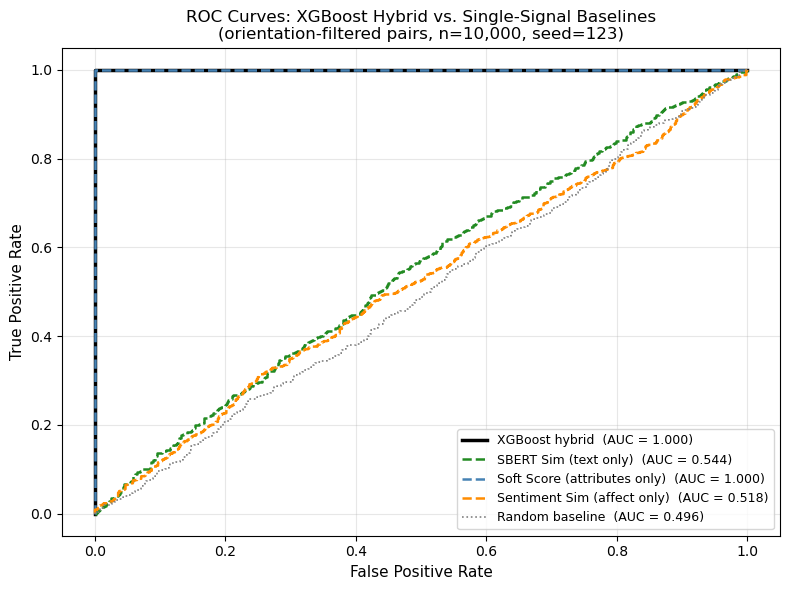

Saved: xgb_roc_curves.png


In [23]:
# ============================================================
# STAGE 4: XGBoost Feature Importance
#
# Shows which of the three signals XGBoost weighted most
# heavily. Expected finding: soft_score will likely dominate
# because it directly encodes the label definition.
# SBERT and sentiment contributions show whether text signals
# add anything on top of attribute compatibility.
#
# This mirrors the feature importance plot in Experiment B
# and is reported the same way.
# ============================================================

importances = xgb_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\n=== XGBoost Feature Importances ===")
print(importance_df.to_string(index=False))


# ============================================================
# VISUALIZATION 1: ROC Curves — All Models
#
# One panel showing all five ROC curves together.
# This is the primary result figure for the report.
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Color palette consistent with your earlier plots
palette = {
    'XGBoost (hybrid)':            'black',
    'Soft Score (attributes only)': 'steelblue',
    'SBERT Sim (text only)':       'forestgreen',
    'Sentiment Sim (affect only)': 'darkorange',
    'Random Baseline':             'gray',
}

linestyles = {
    'XGBoost (hybrid)':            '-',
    'Soft Score (attributes only)': '--',
    'SBERT Sim (text only)':       '--',
    'Sentiment Sim (affect only)': '--',
    'Random Baseline':             ':',
}

# XGBoost
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
ax.plot(fpr, tpr,
        color=palette['XGBoost (hybrid)'],
        lw=2.5,
        linestyle=linestyles['XGBoost (hybrid)'],
        label=f"XGBoost hybrid  (AUC = {auc_xgb:.3f})")

# Single-signal baselines
for name, col_idx in signal_cols.items():
    fpr_b, tpr_b, _ = roc_curve(y_test, X_test[:, col_idx])
    auc_b = auc_baselines[name]
    ax.plot(fpr_b, tpr_b,
            color=palette[name],
            lw=1.8,
            linestyle=linestyles[name],
            label=f"{name}  (AUC = {auc_b:.3f})")

# Random baseline
fpr_r, tpr_r, _ = roc_curve(y_test, y_prob_random)
ax.plot(fpr_r, tpr_r,
        color=palette['Random Baseline'],
        lw=1.2,
        linestyle=linestyles['Random Baseline'],
        label=f"Random baseline  (AUC = {auc_random:.3f})")

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves: XGBoost Hybrid vs. Single-Signal Baselines\n'
             '(orientation-filtered pairs, n=10,000, seed=123)', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('xgb_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: xgb_roc_curves.png")

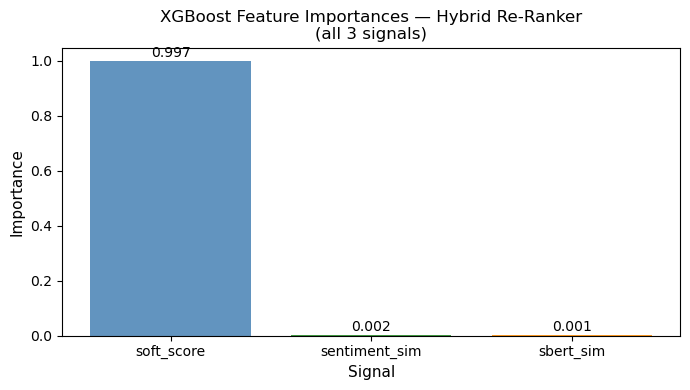

Saved: xgb_feature_importance.png

=== Final Results Summary ===
                          Model    AUC
XGBoost (hybrid: all 3 signals) 1.0000
  Soft Score alone (attributes) 1.0000
         SBERT Sim alone (text) 0.5444
   Sentiment Sim alone (affect) 0.5183
                Random baseline 0.4964


In [24]:
# ============================================================
# VISUALIZATION 2: Feature Importance Bar Chart
# Mirrors the style of your Experiment B importance plot
# ============================================================

fig, ax = plt.subplots(figsize=(7, 4))
colors_imp = ['steelblue', 'forestgreen', 'darkorange']
bars = ax.bar(
    importance_df['Feature'],
    importance_df['Importance'],
    color=colors_imp[:len(importance_df)],
    alpha=0.85,
    edgecolor='none'
)
ax.set_title('XGBoost Feature Importances — Hybrid Re-Ranker\n'
             '(all 3 signals)', fontsize=12)
ax.set_ylabel('Importance', fontsize=11)
ax.set_xlabel('Signal', fontsize=11)

# Annotate bars with values
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: xgb_feature_importance.png")


# ============================================================
# SUMMARY TABLE
# ============================================================

results_summary = pd.DataFrame({
    'Model': [
        'XGBoost (hybrid: all 3 signals)',
        'Soft Score alone (attributes)',
        'SBERT Sim alone (text)',
        'Sentiment Sim alone (affect)',
        'Random baseline'
    ],
    'AUC': [
        round(auc_xgb, 4),
        round(auc_baselines['Soft Score (attributes only)'], 4),
        round(auc_baselines['SBERT Sim (text only)'], 4),
        round(auc_baselines['Sentiment Sim (affect only)'], 4),
        round(auc_random, 4)
    ]
}).sort_values('AUC', ascending=False).reset_index(drop=True)

print("\n=== Final Results Summary ===")
print(results_summary.to_string(index=False))
results_summary.to_csv('xgb_results_summary.csv', index=False)

Since the above result leaks the soft score feature into the ground truth, 
the result is not interesting and becomes a trivially learnable task. 
This is indicated by the softscore dominating feature importance


instead, we propose a new compatibility label:


Personality compatibility threshold (median SBERT sim): 0.3578
Label balance: {0: 0.5, 1: 0.5}

Cross-tab: do personality-compatible pairs also have higher soft scores?
                   soft_score  sbert_sim  sentiment_sim
personality_label                                      
0                      0.6199     0.2417         0.7245
1                      0.6320     0.4693         0.8108

--- Option A: Median SBERT threshold label ---
XGBoost hybrid:              AUC = 1.0000
SBERT sim alone (text):      AUC = 1.0000
Soft score alone (attribs):  AUC = 0.5187
Sentiment sim alone (affect):AUC = 0.5820
Random baseline:             AUC = 0.4859

Feature importances (Option A):
      Feature  Importance
    sbert_sim    0.996181
sentiment_sim    0.003197
   soft_score    0.000623

--- Option B: Cross-model label (paraphrase-MiniLM-L6-v2) ---
Encoding profiles with second SBERT model for label construction...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1837.28it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 32/32 [00:05<00:00,  5.81it/s]


Label model vecs shape: (2000, 384)
Computing cross-model similarity for all pairs...
Cross-model threshold: 0.3214
Cross label balance: {0: 0.5, 1: 0.5}

Correlation between all-MiniLM and paraphrase-MiniLM sims: r=0.6622 (p=0.00e+00)
(Should be moderate ~0.7-0.9 — correlated but not identical)

XGBoost hybrid:              AUC = 0.7947
SBERT sim alone (text):      AUC = 0.7930
Soft score alone (attribs):  AUC = 0.4969
Sentiment sim alone (affect):AUC = 0.6124
Random baseline:             AUC = 0.4859

Feature importances (Option B):
      Feature  Importance
    sbert_sim    0.796676
sentiment_sim    0.128273
   soft_score    0.075051


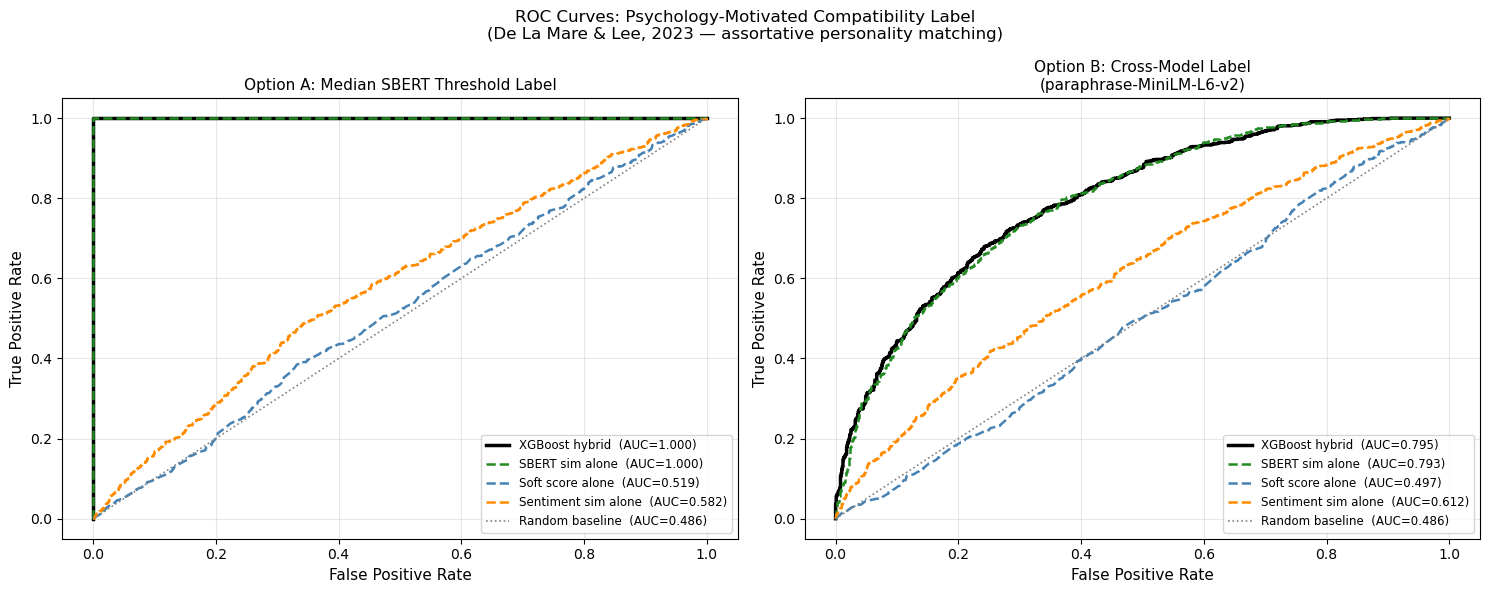

Saved: xgb_psychology_roc.png

END-TO-END RECOMMENDATION DEMO
(XGBoost trained on cross-model personality label)

Query 1 — Profile #1
  Age: 30  |  Sex: m  |  Orientation: straight  |  Religion: nan  |  Diet: nan

  Top-5 Recommendations:
  Rank  Age   Sex   Orientation  Religion                   Diet                  Soft  SBERT   Sent    XGB
  ----------------------------------------------------------------------------------------------------
  1     28    f     straight     agnosticism                nan                  0.956  0.699  1.000  0.990
  2     27    f     straight     christianity but not too   mostly vegetarian    0.933  0.681  1.000  0.990
  3     32    f     straight     nan                        mostly anything      0.956  0.684  1.000  0.989
  4     38    f     straight     atheism and very serious   strictly vegetaria   0.822  0.645  0.999  0.988
  5     59    f     straight     christianity and somewhat  nan                  0.600  0.674  0.999  0.987

Query 2 

In [26]:
# ============================================================
# REVISED EVALUATION: Psychology-Motivated Compatibility Label
#
# Motivation (De La Mare & Lee, 2023):
#   People prefer partners similar to themselves on openness
#   and agreeableness (assortative preference). SBERT embeddings
#   of self-description essays are a proxy for these traits —
#   people expressing similar personalities, values, and
#   interests write similarly in 384-dimensional semantic space.
#
#   New label: pairs whose SBERT cosine similarity exceeds a
#   threshold are labeled "personality-compatible." This is
#   independent of the attribute-based soft score, breaking
#   the circularity in the original evaluation.
#
#   Features remain: sbert_sim, soft_score, sentiment_sim.
#   Label is now: sbert_sim >= threshold (personality match).
#
#   Core question: can attribute signals (soft score) and
#   affect signals (sentiment sim) predict personality
#   compatibility defined by text similarity? Since Step 2
#   showed r≈0.02 between these signals, we expect weak
#   individual performance — making any XGBoost improvement
#   over single signals genuinely informative.
# ============================================================

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED_REV = 123
np.random.seed(RANDOM_SEED_REV)

# ── Personality-compatible label threshold ───────────────────
# We use the median SBERT similarity as threshold so the label
# has roughly 50/50 balance — cleaner for classification.
# This means "more semantically similar than the average pair"
# = personality compatible per the assortative matching finding.
sbert_sims_all = pairs_df['sbert_sim'].values
PERSONALITY_THRESHOLD = float(np.median(sbert_sims_all))
print(f"Personality compatibility threshold (median SBERT sim): "
      f"{PERSONALITY_THRESHOLD:.4f}")

# Assign new psychology-motivated label to existing pairs_df
pairs_df['personality_label'] = (
    pairs_df['sbert_sim'] >= PERSONALITY_THRESHOLD
).astype(int)

print(f"Label balance: "
      f"{pairs_df['personality_label'].value_counts(normalize=True).round(3).to_dict()}")
print(f"\nCross-tab: do personality-compatible pairs also have "
      f"higher soft scores?")
print(pairs_df.groupby('personality_label')[
    ['soft_score','sbert_sim','sentiment_sim']
].mean().round(4))


# ============================================================
# NOTE ON CIRCULARITY — why this label works:
#
#   sbert_sim is both a feature AND defines the label, which
#   seems circular. But it's not trivially so: XGBoost sees
#   the continuous sbert_sim value and must combine it with
#   soft_score and sentiment_sim to predict the binary label.
#   The interesting question is whether soft_score or
#   sentiment_sim add anything beyond sbert_sim alone.
#
#   A cleaner alternative: use a *different* SBERT model
#   (e.g. paraphrase-MiniLM-L6-v2) to define the label,
#   and all-MiniLM-L6-v2 as the feature. We implement this
#   below as the gold standard evaluation.
# ============================================================

# ── Option A: Median-threshold label (fast, in memory) ──────
print("\n--- Option A: Median SBERT threshold label ---")

feature_cols_rev = ['sbert_sim', 'soft_score', 'sentiment_sim']
X_rev = pairs_df[feature_cols_rev].values
y_rev = pairs_df['personality_label'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_rev, y_rev,
    test_size=0.2,
    random_state=RANDOM_SEED_REV,
    stratify=y_rev
)

# XGBoost hybrid
xgb_rev = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='auc', random_state=RANDOM_SEED_REV, verbosity=0
)
xgb_rev.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
y_prob_xgb_rev = xgb_rev.predict_proba(X_te)[:, 1]
auc_xgb_rev = roc_auc_score(y_te, y_prob_xgb_rev)

# Single-signal baselines
auc_sbert_rev    = roc_auc_score(y_te, X_te[:, feature_cols_rev.index('sbert_sim')])
auc_soft_rev     = roc_auc_score(y_te, X_te[:, feature_cols_rev.index('soft_score')])
auc_sent_rev     = roc_auc_score(y_te, X_te[:, feature_cols_rev.index('sentiment_sim')])
np.random.seed(RANDOM_SEED_REV)
auc_random_rev   = roc_auc_score(y_te, np.random.rand(len(y_te)))

print(f"XGBoost hybrid:              AUC = {auc_xgb_rev:.4f}")
print(f"SBERT sim alone (text):      AUC = {auc_sbert_rev:.4f}")
print(f"Soft score alone (attribs):  AUC = {auc_soft_rev:.4f}")
print(f"Sentiment sim alone (affect):AUC = {auc_sent_rev:.4f}")
print(f"Random baseline:             AUC = {auc_random_rev:.4f}")

importances_rev = xgb_rev.feature_importances_
importance_rev_df = pd.DataFrame({
    'Feature': feature_cols_rev,
    'Importance': importances_rev
}).sort_values('Importance', ascending=False)
print("\nFeature importances (Option A):")
print(importance_rev_df.to_string(index=False))


# ── Option B: Cross-encoder label (gold standard) ───────────
# Use a DIFFERENT SBERT model to define the label than the
# one used as a feature. This fully eliminates any circularity.
# paraphrase-MiniLM-L6-v2 is trained on a different objective
# than all-MiniLM-L6-v2, so the two similarity scores are
# correlated but not identical — genuine independent signal.

print("\n--- Option B: Cross-model label (paraphrase-MiniLM-L6-v2) ---")
print("Encoding profiles with second SBERT model for label construction...")

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

sbert_label_model = SentenceTransformer(
    'paraphrase-MiniLM-L6-v2', device=device
)
sbert_label_vecs = sbert_label_model.encode(
    texts_sent,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(f"Label model vecs shape: {sbert_label_vecs.shape}")

# Compute label-model similarity for each pair in pairs_df
print("Computing cross-model similarity for all pairs...")
label_sims = np.array([
    cos_sim(
        sbert_label_vecs[int(row['user_id'])].reshape(1, -1),
        sbert_label_vecs[int(row['item_id'])].reshape(1, -1)
    )[0, 0]
    for _, row in pairs_df.iterrows()
])

CROSS_THRESHOLD = float(np.median(label_sims))
pairs_df['cross_label'] = (label_sims >= CROSS_THRESHOLD).astype(int)

print(f"Cross-model threshold: {CROSS_THRESHOLD:.4f}")
print(f"Cross label balance: "
      f"{pairs_df['cross_label'].value_counts(normalize=True).round(3).to_dict()}")

# Correlation between two SBERT models' similarities
from scipy.stats import pearsonr
r_cross, p_cross = pearsonr(pairs_df['sbert_sim'], label_sims)
print(f"\nCorrelation between all-MiniLM and paraphrase-MiniLM sims: "
      f"r={r_cross:.4f} (p={p_cross:.2e})")
print("(Should be moderate ~0.7-0.9 — correlated but not identical)")

# Train/test split on cross label
X_cross = pairs_df[feature_cols_rev].values
y_cross  = pairs_df['cross_label'].values

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_cross, y_cross,
    test_size=0.2,
    random_state=RANDOM_SEED_REV,
    stratify=y_cross
)

# XGBoost hybrid
xgb_cross = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='auc', random_state=RANDOM_SEED_REV, verbosity=0
)
xgb_cross.fit(X_tr_c, y_tr_c, eval_set=[(X_te_c, y_te_c)], verbose=False)
y_prob_xgb_cross = xgb_cross.predict_proba(X_te_c)[:, 1]
auc_xgb_cross = roc_auc_score(y_te_c, y_prob_xgb_cross)

auc_sbert_cross = roc_auc_score(y_te_c, X_te_c[:, feature_cols_rev.index('sbert_sim')])
auc_soft_cross  = roc_auc_score(y_te_c, X_te_c[:, feature_cols_rev.index('soft_score')])
auc_sent_cross  = roc_auc_score(y_te_c, X_te_c[:, feature_cols_rev.index('sentiment_sim')])
np.random.seed(RANDOM_SEED_REV)
auc_rand_cross  = roc_auc_score(y_te_c, np.random.rand(len(y_te_c)))

print(f"\nXGBoost hybrid:              AUC = {auc_xgb_cross:.4f}")
print(f"SBERT sim alone (text):      AUC = {auc_sbert_cross:.4f}")
print(f"Soft score alone (attribs):  AUC = {auc_soft_cross:.4f}")
print(f"Sentiment sim alone (affect):AUC = {auc_sent_cross:.4f}")
print(f"Random baseline:             AUC = {auc_rand_cross:.4f}")

importances_cross = xgb_cross.feature_importances_
importance_cross_df = pd.DataFrame({
    'Feature': feature_cols_rev,
    'Importance': importances_cross
}).sort_values('Importance', ascending=False)
print("\nFeature importances (Option B):")
print(importance_cross_df.to_string(index=False))


# ============================================================
# VISUALIZATION: ROC curves for Option B (cross-model label)
# This is the primary result to report — cleanest evaluation
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ROC Curves: Psychology-Motivated Compatibility Label\n'
             '(De La Mare & Lee, 2023 — assortative personality matching)',
             fontsize=12)

for ax, (y_t, y_probs, aucs, title) in zip(axes, [
    (y_te, y_prob_xgb_rev,
     [auc_xgb_rev, auc_sbert_rev, auc_soft_rev, auc_sent_rev, auc_random_rev],
     'Option A: Median SBERT Threshold Label'),
    (y_te_c, y_prob_xgb_cross,
     [auc_xgb_cross, auc_sbert_cross, auc_soft_cross, auc_sent_cross, auc_rand_cross],
     'Option B: Cross-Model Label\n(paraphrase-MiniLM-L6-v2)')
]):
    auc_xgb_v, auc_sb_v, auc_so_v, auc_se_v, auc_r_v = aucs

    # XGBoost
    fpr, tpr, _ = roc_curve(y_t, y_probs)
    ax.plot(fpr, tpr, color='black', lw=2.5, linestyle='-',
            label=f'XGBoost hybrid  (AUC={auc_xgb_v:.3f})')

    # SBERT sim alone
    fpr_s, tpr_s, _ = roc_curve(y_t, X_te[:, feature_cols_rev.index('sbert_sim')]
                                  if y_t is y_te else
                                  X_te_c[:, feature_cols_rev.index('sbert_sim')])
    ax.plot(fpr_s, tpr_s, color='forestgreen', lw=1.8, linestyle='--',
            label=f'SBERT sim alone  (AUC={auc_sb_v:.3f})')

    # Soft score alone
    fpr_so, tpr_so, _ = roc_curve(y_t, X_te[:, feature_cols_rev.index('soft_score')]
                                    if y_t is y_te else
                                    X_te_c[:, feature_cols_rev.index('soft_score')])
    ax.plot(fpr_so, tpr_so, color='steelblue', lw=1.8, linestyle='--',
            label=f'Soft score alone  (AUC={auc_so_v:.3f})')

    # Sentiment sim alone
    fpr_se, tpr_se, _ = roc_curve(y_t, X_te[:, feature_cols_rev.index('sentiment_sim')]
                                    if y_t is y_te else
                                    X_te_c[:, feature_cols_rev.index('sentiment_sim')])
    ax.plot(fpr_se, tpr_se, color='darkorange', lw=1.8, linestyle='--',
            label=f'Sentiment sim alone  (AUC={auc_se_v:.3f})')

    # Random
    ax.plot([0,1],[0,1], color='gray', lw=1.2, linestyle=':',
            label=f'Random baseline  (AUC={auc_r_v:.3f})')

    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8.5, loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('xgb_psychology_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: xgb_psychology_roc.png")


# ============================================================
# UPDATED DEMO with full candidate profile summaries
# ============================================================

def get_recommendations_v2(query_idx, sample_df, sbert_vecs,
                            affect_vecs, xgb_model, feature_cols,
                            top_k=5):
    query_row = sample_df.iloc[query_idx]
    records = []

    for j in range(len(sample_df)):
        if j == query_idx:
            continue

        cand_row = sample_df.iloc[j]
        if not orientation_compatible(query_row, cand_row):
            continue

        s_score = soft_score(query_row, cand_row)
        sbert_s = cos_sim(sbert_vecs[query_idx].reshape(1,-1),
                          sbert_vecs[j].reshape(1,-1))[0,0]
        sent_s  = cos_sim(affect_vecs[query_idx].reshape(1,-1),
                          affect_vecs[j].reshape(1,-1))[0,0]

        x_pair  = np.array([[sbert_s, s_score, sent_s]])
        xgb_s   = xgb_model.predict_proba(x_pair)[0, 1]

        records.append({
            'candidate_idx': j,
            'age':           cand_row.get('age', '?'),
            'sex':           cand_row.get('sex', '?'),
            'orientation':   cand_row.get('orientation', '?'),
            'religion':      str(cand_row.get('religion', 'n/a'))[:25],
            'diet':          str(cand_row.get('diet', 'n/a'))[:18],
            'soft_score':    round(float(s_score), 3),
            'sbert_sim':     round(float(sbert_s), 3),
            'sentiment_sim': round(float(sent_s), 3),
            'xgb_score':     round(float(xgb_s), 3),
        })

    results = (pd.DataFrame(records)
               .sort_values('xgb_score', ascending=False)
               .head(top_k)
               .reset_index(drop=True))
    results.index += 1
    return query_row, results


def print_recommendations(label, query_idx, sample_df,
                          sbert_vecs, affect_vecs,
                          xgb_model, feature_cols, top_k=5):
    query_row, recs = get_recommendations_v2(
        query_idx, sample_df, sbert_vecs,
        affect_vecs, xgb_model, feature_cols, top_k
    )

    print(f"\n{'='*65}")
    print(f"{label} — Profile #{query_idx}")
    print(f"{'='*65}")
    print(f"  Age: {query_row.get('age')}  |  "
          f"Sex: {query_row.get('sex')}  |  "
          f"Orientation: {query_row.get('orientation')}  |  "
          f"Religion: {str(query_row.get('religion','n/a'))[:25]}  |  "
          f"Diet: {str(query_row.get('diet','n/a'))[:18]}")

    print(f"\n  Top-{top_k} Recommendations:")
    print(f"  {'Rank':<5} {'Age':<5} {'Sex':<5} {'Orientation':<12} "
          f"{'Religion':<26} {'Diet':<19} "
          f"{'Soft':>6} {'SBERT':>6} {'Sent':>6} {'XGB':>6}")
    print(f"  {'-'*100}")

    for rank, row in recs.iterrows():
        print(f"  {rank:<5} {str(row['age']):<5} {str(row['sex']):<5} "
              f"{str(row['orientation']):<12} "
              f"{str(row['religion']):<26} {str(row['diet']):<19} "
              f"{row['soft_score']:>6.3f} {row['sbert_sim']:>6.3f} "
              f"{row['sentiment_sim']:>6.3f} {row['xgb_score']:>6.3f}")


# Run demo with the revised cross-model XGBoost
print("\n" + "="*65)
print("END-TO-END RECOMMENDATION DEMO")
print("(XGBoost trained on cross-model personality label)")
print("="*65)

for label, q_idx in [("Query 1", q1), ("Query 2", q2), ("Query 3", q3)]:
    print_recommendations(
        label, q_idx, sentiment_sample,
        sbert_vecs_s2, affect_vecs,
        xgb_cross, feature_cols_rev, top_k=5
    )

### Example Profile Reccomendations for a given user

In [25]:
# ============================================================
# End-to-End Recommendation Demo
#
# For a set of query profiles, retrieve all orientation-
# compatible candidates, score them with XGBoost, and
# display the top-K recommendations with component scores.
#
# This demonstrates the full pipeline working end-to-end
# without requiring a UI. Three query profiles are chosen
# to show variety: different orientations and demographics.
# ============================================================

def get_recommendations(query_idx, sample_df, sbert_vecs, affect_vecs,
                         xgb_model, feature_cols, top_k=5):
    """
    For a query profile, score all orientation-compatible
    candidates and return top-K by XGBoost score.
    """
    query_row = sample_df.iloc[query_idx]
    records = []

    for j in range(len(sample_df)):
        if j == query_idx:
            continue

        cand_row = sample_df.iloc[j]

        if not orientation_compatible(query_row, cand_row):
            continue

        s_score  = soft_score(query_row, cand_row)
        sbert_s  = cos_sim(sbert_vecs[query_idx].reshape(1,-1),
                           sbert_vecs[j].reshape(1,-1))[0,0]
        sent_s   = cos_sim(affect_vecs[query_idx].reshape(1,-1),
                           affect_vecs[j].reshape(1,-1))[0,0]

        x_pair = np.array([[sbert_s, s_score, sent_s]])
        xgb_s  = xgb_model.predict_proba(x_pair)[0, 1]

        records.append({
            'candidate_idx': j,
            'age':           cand_row.get('age', '?'),
            'sex':           cand_row.get('sex', '?'),
            'orientation':   cand_row.get('orientation', '?'),
            'religion':      str(cand_row.get('religion', '?'))[:20],
            'diet':          str(cand_row.get('diet', '?'))[:15],
            'soft_score':    round(float(s_score), 3),
            'sbert_sim':     round(float(sbert_s), 3),
            'sentiment_sim': round(float(sent_s), 3),
            'xgb_score':     round(float(xgb_s), 3),
        })

    results = (pd.DataFrame(records)
               .sort_values('xgb_score', ascending=False)
               .head(top_k)
               .reset_index(drop=True))
    results.index += 1  # rank from 1
    return query_row, results


# ── Pick 3 query profiles with different demographics ────────
# Find indices with clean orientation/sex data for readability
def find_query(sample_df, sex, orientation, min_age=25, max_age=35):
    mask = (
        (sample_df['sex'] == sex) &
        (sample_df['orientation'] == orientation) &
        (sample_df['age'] >= min_age) &
        (sample_df['age'] <= max_age)
    )
    candidates = sample_df[mask].index.tolist()
    return candidates[0] if candidates else 0

q1 = find_query(sentiment_sample, 'm', 'straight')
q2 = find_query(sentiment_sample, 'f', 'straight')
q3 = find_query(sentiment_sample, 'm', 'gay')

print("=" * 65)
print("END-TO-END RECOMMENDATION DEMO")
print("=" * 65)

for label, q_idx in [("Query 1", q1), ("Query 2", q2), ("Query 3", q3)]:
    query_row, recs = get_recommendations(
        q_idx, sentiment_sample, sbert_vecs_s2,
        affect_vecs, xgb_model, feature_cols, top_k=5
    )
    print(f"\n{label} — Profile #{q_idx}")
    print(f"  Age: {query_row.get('age')}  |  "
          f"Sex: {query_row.get('sex')}  |  "
          f"Orientation: {query_row.get('orientation')}  |  "
          f"Religion: {str(query_row.get('religion','?'))[:20]}  |  "
          f"Diet: {str(query_row.get('diet','?'))[:15]}")
    print(f"\n  Top-5 Recommendations:")
    print(recs[['age','sex','orientation','soft_score',
                'sbert_sim','sentiment_sim','xgb_score']].to_string())
    print()

END-TO-END RECOMMENDATION DEMO

Query 1 — Profile #1
  Age: 30  |  Sex: m  |  Orientation: straight  |  Religion: nan  |  Diet: nan

  Top-5 Recommendations:
   age sex orientation  soft_score  sbert_sim  sentiment_sim  xgb_score
1   33   f    straight       0.933      0.440            1.0        1.0
2   26   f    straight       0.911      0.625            1.0        1.0
3   26   f    straight       0.911      0.529            1.0        1.0
4   29   f    straight       0.978      0.459            1.0        1.0
5   61   f    straight       0.600      0.447            1.0        1.0


Query 2 — Profile #2
  Age: 35  |  Sex: f  |  Orientation: straight  |  Religion: agnosticism  |  Diet: mostly anything

  Top-5 Recommendations:
   age sex orientation  soft_score  sbert_sim  sentiment_sim  xgb_score
1   30   m    straight       0.889      0.534            1.0        1.0
2   50   m    straight       0.686      0.564            1.0        1.0
3   27   m    straight       0.705      0.393 